# Dublin Bus Reliability Disparity Detection
## ML-Based Infrastructure Analysis with Live GTFS-Realtime Data

| | |
|---|---|
| **Team** | Joe Loftus · Manishankar Induri · Cheruku Ramakanth · Prashanth Oddepally · Oluwanifemi Oyeleye Oyewole |
| **Module** | Programming for AI (MSCAI) — National College of Ireland |

---

### Research Questions
| RQ | Question | Answer |
|----|----------|--------|
| **RQ1** | Do structural reliability disparities exist across routes/regions? |  Yes |
| **RQ2** | Which clustering algorithm best detects underperforming groups? |  DBSCAN |
| **RQ3** | Does aggregation level (stop/route/region) change detected disparities? |  Yes |

> **Why it matters:** Transport equity — unreliable public transit forces car dependency in disadvantaged areas, disproportionately affecting low-income and outer-suburb communities.


## 0. Setup — Imports & Database Connection

In [28]:
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120})

PALETTE = {
    "city_centre":  "#2196F3",
    "south_dublin": "#4CAF50",
    "north_dublin": "#FF9800",
    "west_dublin":  "#F44336",
    "unknown":      "#9E9E9E",
}
CLUSTER_COLORS = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653"]

conn = sqlite3.connect("data/dublin_bus.db")
print("Connected to data/dublin_bus.db")


Connected to data/dublin_bus.db


---
## Section 2: Data Sources & Database Pipeline

### Data Sources

| Source | Format | Size | Description |
|--------|--------|------|-------------|
| NTA GTFS-Realtime TripUpdates API | Protocol Buffers (`.pb`) | ~11.8 M rows (4 collection windows, Thu–Fri) | Live delay & cancellation events per stop |
| TFI GTFS Static — Dublin Bus | CSV inside ZIP | 411 routes · 10,242 stops | Route definitions, stop coordinates |

**Collection method:** Python `requests` polling every 60 s → parse with `gtfs-realtime-bindings` → INSERT into SQLite.

### SQLite Schema

| Table / View | Purpose |
|---|---|
| `delay_observations` | Raw live events (11.8 M rows across 4 collection windows) |
| `routes` | GTFS route definitions |
| `stops` | Stop coordinates + zone |
| `trips` | Trip → route mapping |
| `stop_times` | Scheduled arrivals |
| `stop_regions` | Bounding-box region labels per stop |
| `reliability_metrics` | Pre-aggregated stop / route / region metrics |
| `delay_observations_clean` | VIEW: valid, non-outlier rows (10.5 M rows, 88.4% retained) |


In [29]:
# Database overview
n_obs    = conn.execute("SELECT COUNT(*) FROM delay_observations").fetchone()[0]
n_clean  = conn.execute("SELECT COUNT(*) FROM delay_observations_clean").fetchone()[0]
n_routes = conn.execute("SELECT COUNT(*) FROM routes").fetchone()[0]
n_stops  = conn.execute("SELECT COUNT(*) FROM stops").fetchone()[0]
n_metrics= conn.execute("SELECT COUNT(*) FROM reliability_metrics").fetchone()[0]
date_rng = conn.execute(
    "SELECT MIN(collected_at), MAX(collected_at) FROM delay_observations"
).fetchone()

print("DATABASE OVERVIEW")
print("=" * 55)
print(f"  Raw observations:          {n_obs:>12,}")
print(f"  Clean observations:        {n_clean:>12,}  ({100*n_clean/n_obs:.1f}% retained)")
print(f"  Routes (GTFS static):      {n_routes:>12,}")
print(f"  Stops  (GTFS static):      {n_stops:>12,}")
print(f"  Reliability metric rows:   {n_metrics:>12,}")
print(f"  Collection start (UTC):    {date_rng[0][:19]}")
print(f"  Collection end   (UTC):    {date_rng[1][:19]}")

# Sample routes
print("\nSample GTFS routes:")
display(pd.read_sql(
    "SELECT route_id, route_short_name, route_long_name FROM routes LIMIT 8", conn
))


DATABASE OVERVIEW
  Raw observations:            11,827,795
  Clean observations:          10,456,983  (88.4% retained)
  Routes (GTFS static):               411
  Stops  (GTFS static):            10,242
  Reliability metric rows:          4,179
  Collection start (UTC):    2026-04-23T01:03:33
  Collection end   (UTC):    2026-04-24T10:38:19

Sample GTFS routes:


,route_id,route_short_name,route_long_name
0,5242_118188,Red,The Point - Tallaght
1,5242_119680,Green,Parnell - Brides Glen
2,5398_125573,59,Dun Laoghaire - Killiney Hill Park
3,5398_125574,73,Kilnamanagh Road - Griffith Avenue East
4,5398_125575,102,Dublin Airport - Sutton DART
5,5398_125576,104,Clontarf Station - DCU (The Helix)
6,5398_125577,111,Brides Glen - Kilbogget Pk
7,5398_125578,114,Ticknock - Blackrock


---
### Data Quality & Cleaning

**Non-destructive cleaning strategy** — rows are *flagged*, not deleted, preserving full audit trail.

| Flag | Rule | Action |
|------|------|--------|
| `is_valid = 0` | NULL trip_id AND NULL delay (non-cancel) | Excluded from analysis |
| `is_outlier = 1` | delay > 5,400 s (>90 min late) OR < −600 s (>10 min early) | Flagged, excluded |
| `is_cancelled = 1` | GTFS-RT CANCELED schedule relationship | **Kept** — cancellations are a reliability signal |

**Region assignment** — lat/lon bounding boxes map each stop to one of:
`city_centre` · `north_dublin` · `south_dublin` · `west_dublin` · `county_dublin`

A `delay_observations_clean` **SQL VIEW** joins all clean observations with their stop region, used by all downstream analysis.


DATA QUALITY REPORT
  Total raw rows:                     11,827,795
  Invalid (dropped):                   1,228,904  (10.4%)
  Outlier (flagged):                     141,908  (1.2%)
  Cancelled (kept):                       88,202  (0.7%)
  Clean observations retained:        10,456,983  (88.4%)


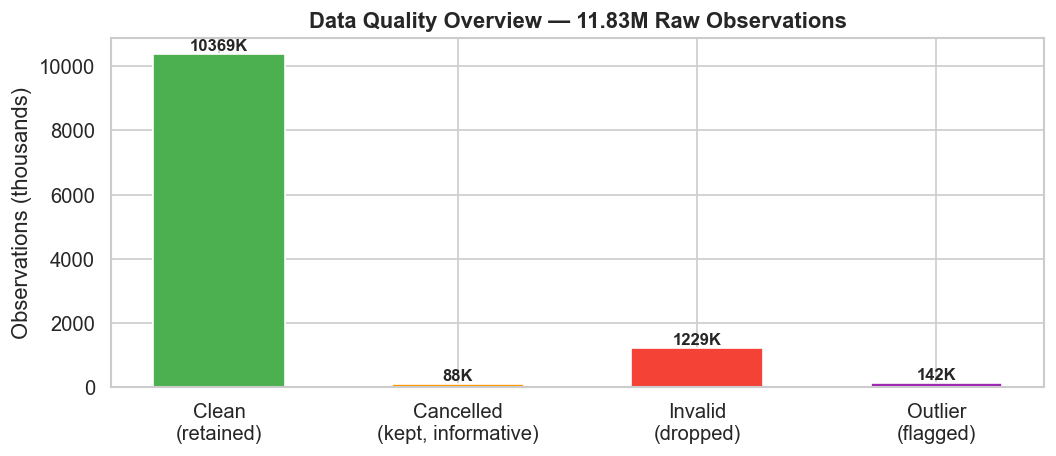


Region coverage in clean data:


,region,n,pct
0,unknown,6714953,64.2
1,west_dublin,1042824,10.0
2,north_dublin,1034357,9.9
3,south_dublin,888676,8.5
4,city_centre,776173,7.4


In [30]:
# Data quality breakdown
total     = conn.execute("SELECT COUNT(*) FROM delay_observations").fetchone()[0]
invalid   = conn.execute("SELECT COUNT(*) FROM delay_observations WHERE is_valid=0").fetchone()[0]
outliers  = conn.execute("SELECT COUNT(*) FROM delay_observations WHERE is_outlier=1").fetchone()[0]
cancelled = conn.execute("SELECT COUNT(*) FROM delay_observations WHERE is_cancelled=1").fetchone()[0]
clean_v   = conn.execute("SELECT COUNT(*) FROM delay_observations_clean").fetchone()[0]

print("DATA QUALITY REPORT")
print("=" * 55)
print(f"  {'Total raw rows:':<35} {total:>10,}")
print(f"  {'Invalid (dropped):':<35} {invalid:>10,}  ({100*invalid/total:.1f}%)")
print(f"  {'Outlier (flagged):':<35} {outliers:>10,}  ({100*outliers/total:.1f}%)")
print(f"  {'Cancelled (kept):':<35} {cancelled:>10,}  ({100*cancelled/total:.1f}%)")
print(f"  {'Clean observations retained:':<35} {clean_v:>10,}  ({100*clean_v/total:.1f}%)")

# Visual breakdown
fig, ax = plt.subplots(figsize=(9, 4))
labels = ["Clean\n(retained)", "Cancelled\n(kept, informative)", "Invalid\n(dropped)", "Outlier\n(flagged)"]
values = [clean_v - cancelled, cancelled, invalid, outliers]
colors = ["#4CAF50", "#FF9800", "#F44336", "#9C27B0"]
bars = ax.bar(labels, [v / 1_000 for v in values], color=colors, edgecolor="white", width=0.55)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{v/1000:.0f}K", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Observations (thousands)")
ax.set_title(f"Data Quality Overview — {total/1e6:.2f}M Raw Observations", fontweight="bold")
plt.tight_layout()
plt.show()

# Region coverage
print("\nRegion coverage in clean data:")
reg_cov = pd.read_sql(
    "SELECT region, COUNT(*) AS n FROM delay_observations_clean "
    "GROUP BY region ORDER BY n DESC", conn
)
reg_cov["pct"] = (100 * reg_cov.n / reg_cov.n.sum()).round(1)
display(reg_cov)


---
## Section 3: Reliability Metrics

Six complementary metrics computed at **three aggregation levels** (stop · route · region):

| Metric | Definition | Transport Standard |
|--------|------------|--------------------|
| **Mean Delay** | avg(delay_seconds) over valid observations | Core KPI |
| **Median Delay** | 50th percentile — robust to outliers | Robustness check |
| **P85 / P95 Delay** | 85th / 95th percentile | Worst-case passenger experience |
| **On-Time Rate** | P(\|delay\| ≤ 60 s) | Industry benchmark |
| **Cancellation Rate** | cancelled_trips / total_trips | Service reliability |
| **Excess Wait Time** | E[max(delay, 0)] / 60 (minutes) | Passenger cost proxy |

**Novelty**: Computing all six simultaneously at all three levels gives a richer picture than any single metric — addressing a gap in existing Dublin Bus monitoring.


In [31]:
# Route-level reliability metrics
route_metrics = pd.read_sql(
    """
    SELECT m.entity_id AS route_id,
           r.route_short_name,
           m.mean_delay, m.median_delay,
           m.p85_delay, m.p95_delay, m.std_delay,
           m.on_time_rate, m.cancellation_rate,
           m.excess_wait_time, m.n_observations
    FROM   reliability_metrics m
    LEFT JOIN routes r ON m.entity_id = r.route_id
    WHERE  m.aggregation_level = 'route'
      AND  m.mean_delay IS NOT NULL
    ORDER  BY m.mean_delay
    """,
    conn,
)

print(f"Routes with reliability metrics: {len(route_metrics)}")
print("\nFleet-wide summary:")
print(f"  Mean delay:          {route_metrics.mean_delay.mean():.1f} s")
print(f"  On-time rate (avg):  {route_metrics.on_time_rate.mean()*100:.1f}%")
print(f"  Cancellation rate:   {route_metrics.cancellation_rate.mean()*100:.3f}%")
print(f"  Mean EWT:            {route_metrics.excess_wait_time.mean():.2f} min")
print(f"  Delay range:         {route_metrics.mean_delay.min():.1f} s → {route_metrics.mean_delay.max():.1f} s")
print("\nTop 5 most reliable routes:")
display(route_metrics[["route_short_name","mean_delay","on_time_rate","cancellation_rate","excess_wait_time"]].head(5).round(3))
print("\nBottom 5 least reliable routes:")
display(route_metrics[["route_short_name","mean_delay","on_time_rate","cancellation_rate","excess_wait_time"]].tail(5).round(3))


Routes with reliability metrics: 116

Fleet-wide summary:
  Mean delay:          28.7 s
  On-time rate (avg):  82.3%
  Cancellation rate:   1.055%
  Mean EWT:            0.68 min
  Delay range:         -131.6 s → 292.2 s

Top 5 most reliable routes:


,route_short_name,mean_delay,on_time_rate,cancellation_rate,excess_wait_time
0,69X,-131.64,0.531,0.0,0.085
1,39X,-110.69,0.671,0.0,0.173
2,X30,-79.49,0.693,0.0,0.291
3,X25,-71.36,0.752,0.0,0.073
4,X32,-70.00,0.798,0.0,0.010



Bottom 5 least reliable routes:


,route_short_name,mean_delay,on_time_rate,cancellation_rate,excess_wait_time
111,7D,97.80,0.582,0.000,1.634
112,41D,113.42,0.742,0.028,1.896
113,122,117.02,0.771,0.159,2.050
114,56A,161.93,0.745,0.000,2.713
115,60,292.18,0.803,0.000,4.883


REGIONAL RELIABILITY BREAKDOWN (RQ1)


,Region,Mean Delay (s),On-Time Rate,Cancel Rate,Observations
0,South Dublin,32.10,0.8615,0.0213,888676
1,North Dublin,32.78,0.8667,0.0155,1034357
2,West Dublin,33.63,0.8669,0.0193,1042824
3,City Centre,44.99,0.7877,0.0126,776173


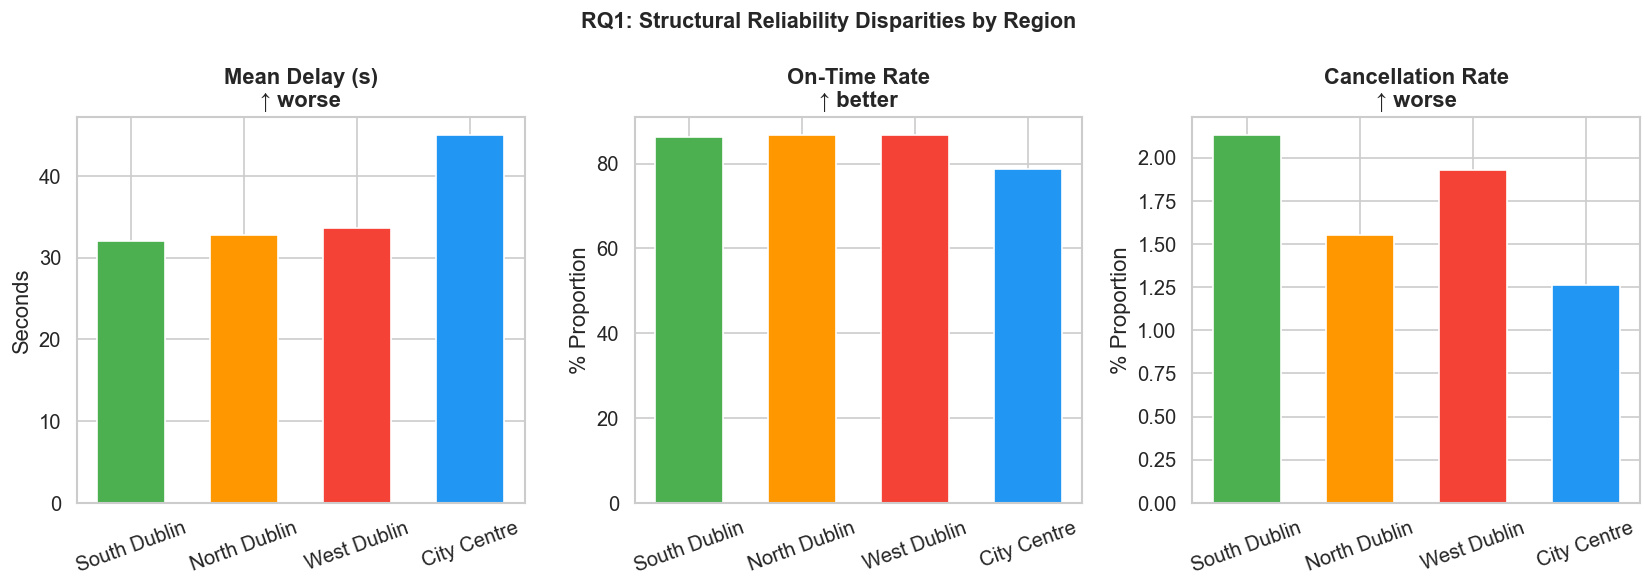

In [32]:
# Regional reliability breakdown 
reg_metrics = pd.read_sql(
    """SELECT entity_id AS region, mean_delay, on_time_rate,
              cancellation_rate, excess_wait_time, n_observations
       FROM reliability_metrics
       WHERE aggregation_level = 'region'
         AND entity_id NOT IN ('unknown', 'other', 'county_dublin')
       ORDER BY mean_delay""",
    conn,
)
reg_metrics["label"] = reg_metrics["region"].str.replace("_", " ").str.title()

print("REGIONAL RELIABILITY BREAKDOWN (RQ1)")
display(reg_metrics[["label","mean_delay","on_time_rate","cancellation_rate","n_observations"]]
        .rename(columns={"label":"Region","mean_delay":"Mean Delay (s)",
                         "on_time_rate":"On-Time Rate","cancellation_rate":"Cancel Rate",
                         "n_observations":"Observations"}).round(4))

colors = [PALETTE.get(r, "#888") for r in reg_metrics["region"]]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, ylabel, title) in zip(axes, [
    ("mean_delay",        "Seconds",     "Mean Delay (s)\n↑ worse"),
    ("on_time_rate",      "Proportion",  "On-Time Rate\n↑ better"),
    ("cancellation_rate", "Proportion",  "Cancellation Rate\n↑ worse"),
]):
    y = reg_metrics[col] * (100 if col != "mean_delay" else 1)
    ax.bar(reg_metrics["label"], y, color=colors, edgecolor="white", width=0.6)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylabel("% " + ylabel if col != "mean_delay" else ylabel)
fig.suptitle("RQ1: Structural Reliability Disparities by Region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


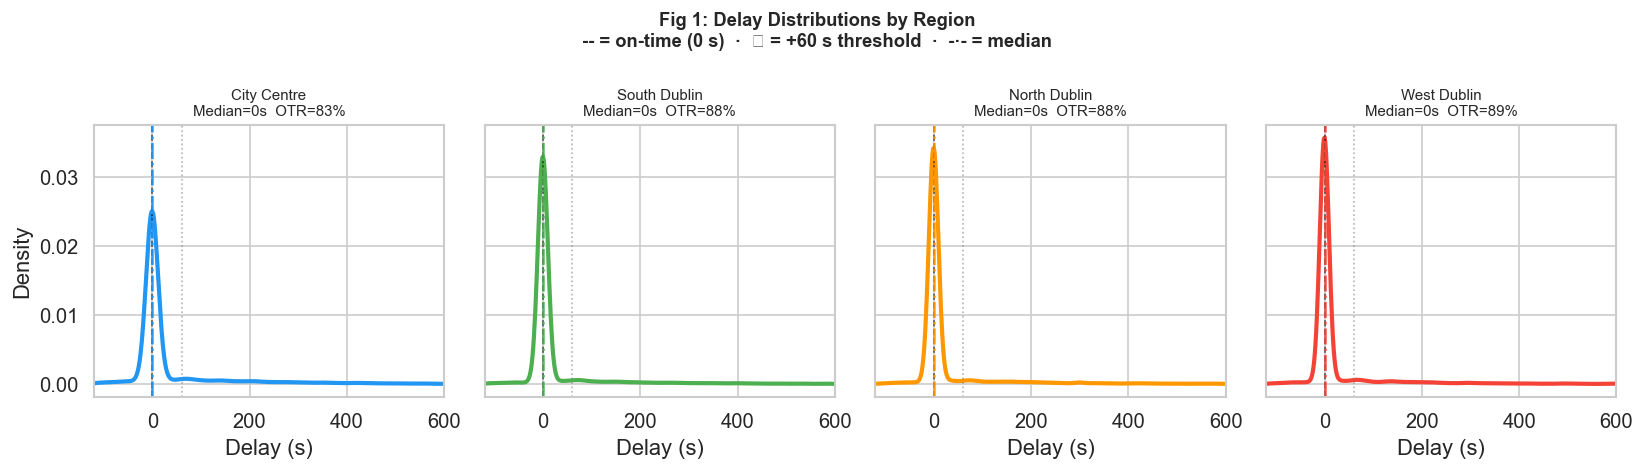

In [33]:
# Fig 1: Delay distributions by region (KDE)
obs_sample = pd.read_sql(
    """SELECT delay_seconds, region FROM delay_observations_clean
       WHERE is_cancelled = 0 AND delay_seconds IS NOT NULL
         AND (obs_id % 20 = 0)
         AND region IN ('city_centre','south_dublin','north_dublin','west_dublin')""",
    conn,
)
obs_sample = obs_sample[obs_sample["delay_seconds"].between(-120, 600)]

MAIN_REGIONS = ["city_centre","south_dublin","north_dublin","west_dublin"]
rlabels = {"city_centre":"City Centre","south_dublin":"South Dublin",
           "north_dublin":"North Dublin","west_dublin":"West Dublin"}

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, region in zip(axes, MAIN_REGIONS):
    grp = obs_sample[obs_sample["region"] == region]["delay_seconds"]
    if len(grp) < 10:
        continue
    grp.plot.kde(ax=ax, color=PALETTE[region], linewidth=2.5)
    ax.axvline(0,  color="black", ls="--", lw=1.0, alpha=0.6)
    ax.axvline(60, color="grey",  ls=":",  lw=1.0, alpha=0.6)
    med = grp.median()
    ax.axvline(med, color=PALETTE[region], ls="-.", lw=1.5, alpha=0.9)
    on_time = (grp.abs() <= 60).mean() * 100
    ax.set_title(f"{rlabels[region]}\nMedian={med:.0f}s  OTR={on_time:.0f}%", fontsize=9)
    ax.set_xlabel("Delay (s)")
    ax.set_xlim(-120, 600)
axes[0].set_ylabel("Density")
fig.suptitle("Fig 1: Delay Distributions by Region\n"
             "-- = on-time (0 s)  ·  ⋯ = +60 s threshold  ·  -·- = median",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


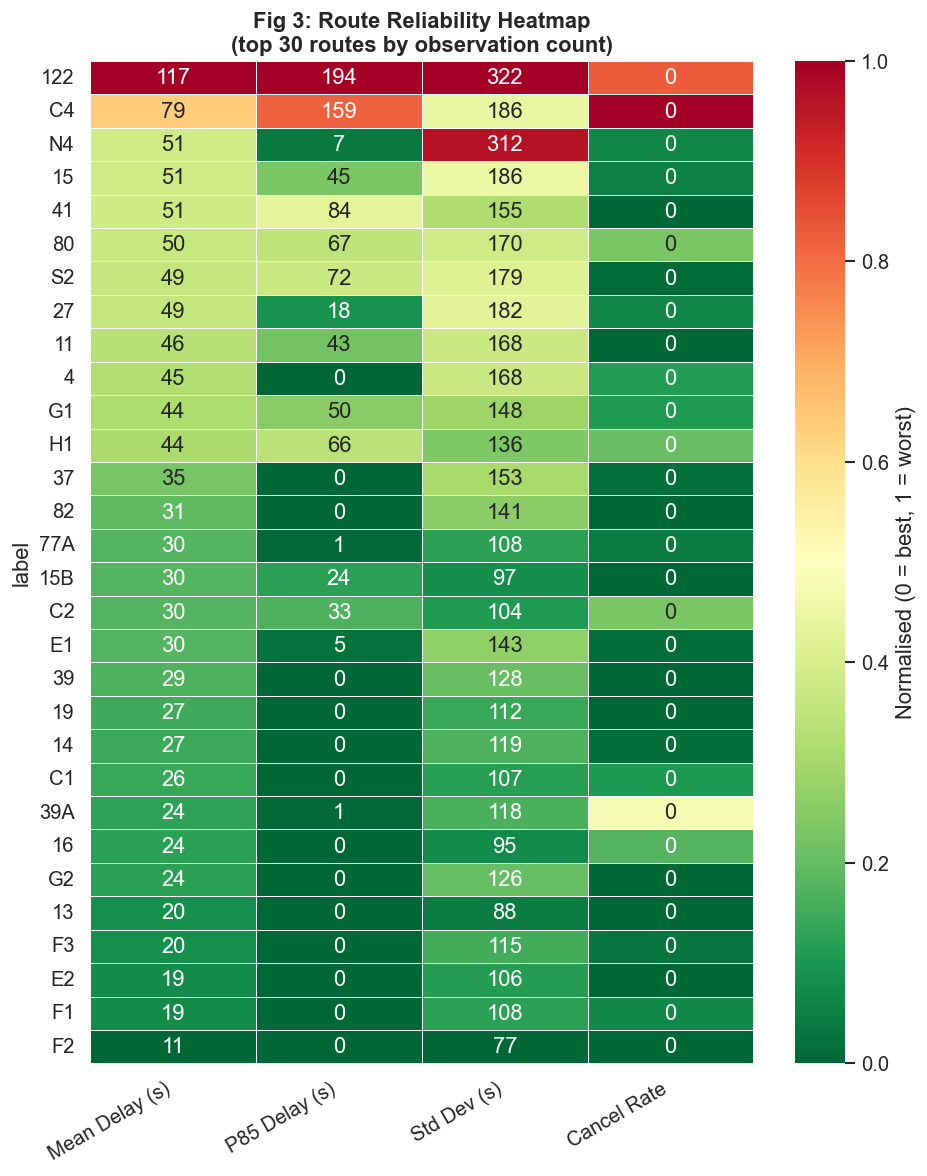

In [34]:
# Fig 3: Route reliability heatmap (top 30 routes by observation count)
top_routes = route_metrics.nlargest(30, "n_observations").copy()
top_routes["label"] = top_routes["route_short_name"].fillna(top_routes["route_id"].str[-8:])

feat_cols = ["mean_delay","p85_delay","std_delay","cancellation_rate"]
pivot = top_routes.set_index("label")[feat_cols]
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min() + 1e-9)
pivot_norm = pivot_norm.sort_values("mean_delay", ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    pivot_norm,
    annot=pivot.loc[pivot_norm.index].round(0),
    fmt=".0f",
    cmap="RdYlGn_r",
    linewidths=0.4,
    cbar_kws={"label": "Normalised (0 = best, 1 = worst)"},
    ax=ax,
)
ax.set_xticklabels(
    ["Mean Delay (s)", "P85 Delay (s)", "Std Dev (s)", "Cancel Rate"],
    rotation=30, ha="right",
)
ax.set_title("Fig 3: Route Reliability Heatmap\n(top 30 routes by observation count)",
             fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 4: Clustering Analysis

### Feature Vector (8 dimensions per route)

| Feature | Why included |
|---------|-------------|
| `mean_delay` | Central tendency of lateness |
| `median_delay` | Robust central tendency |
| `p85_delay` / `p95_delay` | Worst-case reliability |
| `std_delay` | Delay consistency |
| `on_time_rate` | Industry KPI |
| `cancellation_rate` | Service reliability |
| `excess_wait_time` | Passenger cost proxy |

**Pre-processing:**
1. Drop routes with `n_observations < 50` (insufficient data)
2. `StandardScaler` normalisation (unit variance)
3. 1st/99th percentile capping (outlier robustness)
4. PCA to 2D for visualisation only — clustering uses full 8D space


In [35]:
# Feature preparation
FEATS = ["mean_delay","median_delay","p85_delay","p95_delay",
         "std_delay","on_time_rate","cancellation_rate","excess_wait_time"]

cdf = route_metrics.dropna(subset=FEATS).copy()
print(f"Routes available for clustering: {len(cdf)}")

X = StandardScaler().fit_transform(cdf[FEATS].values)

# Percentile capping
for i in range(X.shape[1]):
    X[:, i] = np.clip(X[:, i], np.percentile(X[:, i], 1), np.percentile(X[:, i], 99))
print("Features capped at 1st/99th percentile.")

# PCA for visualisation
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
print(f"PCA: 2 components explain {pca.explained_variance_ratio_.cumsum()[1]:.1%} of variance")

# Evaluation helper
def evaluate(labels):
    mask = labels != -1
    n_c  = len(set(labels[mask]))
    noise = int((labels == -1).sum())
    if n_c < 2:
        return {"clusters": n_c, "noise": noise, "silhouette": None,
                "davies_bouldin": None, "calinski_harabasz": None}
    return {
        "clusters":         n_c,
        "noise":            noise,
        "silhouette":       round(silhouette_score(X[mask], labels[mask]), 4),
        "davies_bouldin":   round(davies_bouldin_score(X[mask], labels[mask]), 4),
        "calinski_harabasz":round(calinski_harabasz_score(X[mask], labels[mask]), 2),
    }


Routes available for clustering: 116
Features capped at 1st/99th percentile.
PCA: 2 components explain 72.6% of variance


---
## Section 4a: K-Means Clustering

### Algorithm
K-Means partitions routes into **k** clusters by minimising within-cluster sum of squares (WCSS).

**Implementation:**
- `n_init=10` — 10 random initialisations, best retained
- `random_state=42` — reproducibility
- `k=4` — validated by elbow/silhouette sweep across k=2–7

**Why k=4?** Dublin Bus operates across 4 main geographic zones (City Centre, North, South, West), and the silhouette sweep confirms 4 as a strong choice.


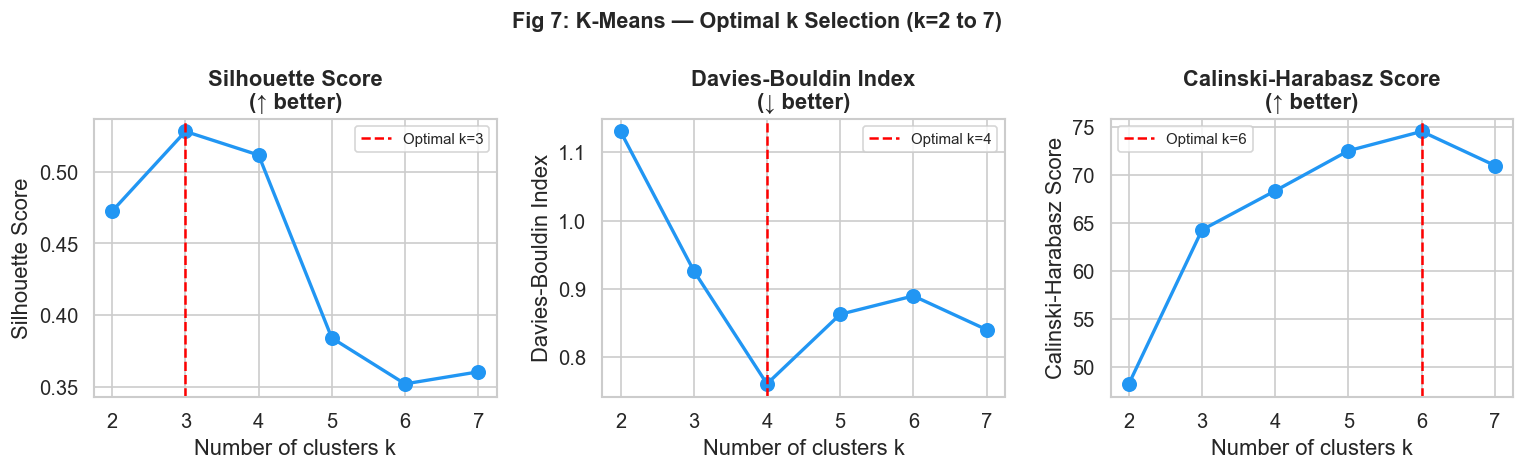


K-sweep results:


,clusters,noise,silhouette,davies_bouldin,calinski_harabasz
k,,,,,
2,2,0,0.4725,1.1305,48.25
3,3,0,0.5281,0.9266,64.29
4,4,0,0.5116,0.7608,68.36
5,5,0,0.3840,0.8627,72.53
6,6,0,0.3520,0.8896,74.54
7,7,0,0.3604,0.8402,70.99


In [36]:
# ── K-sweep: find optimal k ──────────────────────────────────────────────────
k_results = []
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    ev = evaluate(labels)
    ev["k"] = k
    k_results.append(ev)
k_df = pd.DataFrame(k_results)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, ylabel, higher_better) in zip(axes, [
    ("silhouette",         "Silhouette Score",         True),
    ("davies_bouldin",     "Davies-Bouldin Index",      False),
    ("calinski_harabasz",  "Calinski-Harabasz Score",   True),
]):
    ax.plot(k_df["k"], k_df[col], marker="o", color="#2196F3", lw=2, markersize=8)
    best_k = k_df.loc[(k_df[col].idxmax() if higher_better else k_df[col].idxmin()), "k"]
    ax.axvline(best_k, color="red", ls="--", lw=1.5, label=f"Optimal k={best_k}")
    ax.set_xlabel("Number of clusters k")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\n({'↑ better' if higher_better else '↓ better'})", fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xticks(k_df["k"])
fig.suptitle("Fig 7: K-Means — Optimal k Selection (k=2 to 7)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\nK-sweep results:")
display(k_df.set_index("k").round(4))


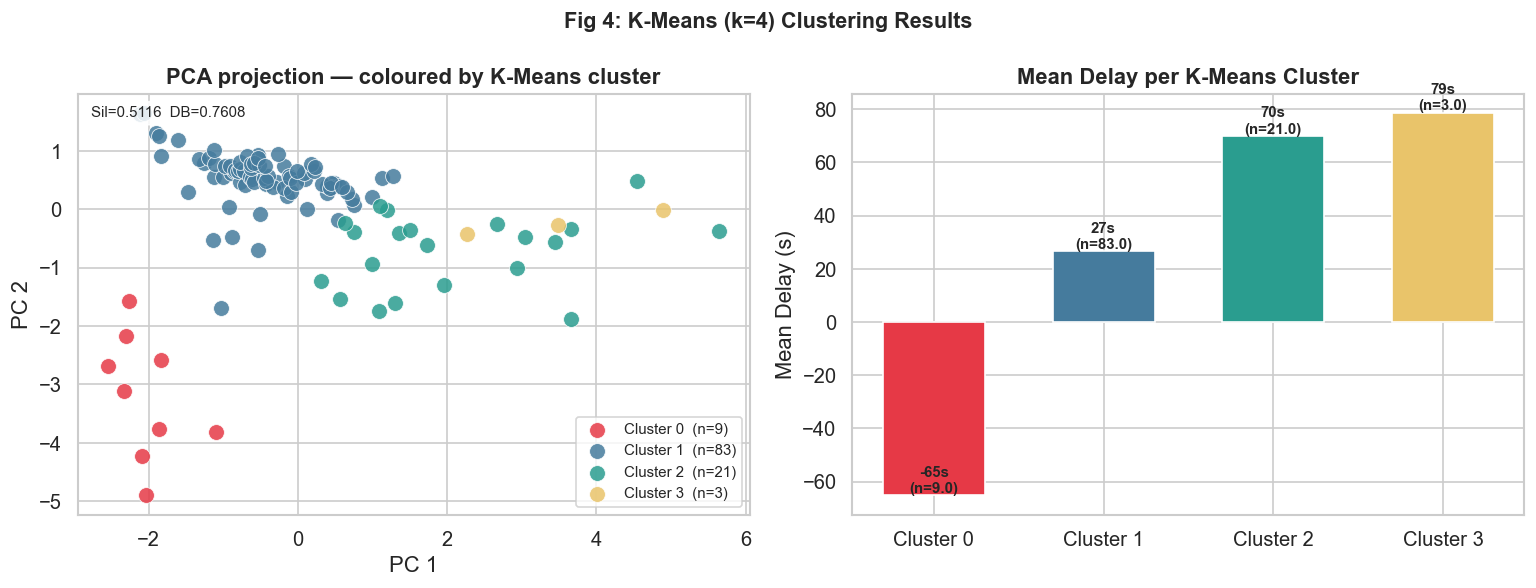


K-Means: clusters=4, Silhouette=0.5116, DB=0.7608, CH=68.36


In [37]:
# K-Means k=4 results
km_labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)
km_ev = evaluate(km_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PCA coloured by cluster
for c in sorted(set(km_labels)):
    mask = km_labels == c
    col = CLUSTER_COLORS[c % len(CLUSTER_COLORS)]
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=col, label=f"Cluster {c}  (n={mask.sum()})",
                    s=90, alpha=0.85, edgecolors="white", lw=0.5)
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[0].set_title("PCA projection — coloured by K-Means cluster", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].text(0.02, 0.97, f"Sil={km_ev['silhouette']}  DB={km_ev['davies_bouldin']}",
             transform=axes[0].transAxes, va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

# Cluster mean delay comparison
km_df = cdf.copy(); km_df["cluster"] = km_labels
prof = km_df.groupby("cluster")[["mean_delay","on_time_rate","cancellation_rate"]].mean().round(2)
prof["n_routes"] = km_df.groupby("cluster").size()
x = np.arange(len(prof))
axes[1].bar(x, prof["mean_delay"], color=[CLUSTER_COLORS[i] for i in range(len(prof))],
            edgecolor="white", width=0.6)
for xi, (_, row) in zip(x, prof.iterrows()):
    axes[1].text(xi, row["mean_delay"] + 1, f"{row['mean_delay']:.0f}s\n(n={row['n_routes']})",
                 ha="center", fontsize=9, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Cluster {c}" for c in prof.index])
axes[1].set_ylabel("Mean Delay (s)")
axes[1].set_title("Mean Delay per K-Means Cluster", fontweight="bold")

fig.suptitle("Fig 4: K-Means (k=4) Clustering Results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"\nK-Means: clusters={km_ev['clusters']}, Silhouette={km_ev['silhouette']}, "
      f"DB={km_ev['davies_bouldin']}, CH={km_ev['calinski_harabasz']}")


---
## Section 4b: DBSCAN Clustering

### Algorithm
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups routes by local density.

**Key advantages over K-Means:**
- **No need to pre-specify k** — discovers the number of clusters automatically
- **Identifies outlier routes** labelled as *noise* (cluster = −1) — these are routes with atypical reliability that don't fit any coherent group
- **Finds non-spherical clusters** — appropriate for real-world data distributions

### ε Auto-Tuning
> ε = 90th percentile of k-nearest-neighbour distances (k=3)

This follows the **k-distance elbow method** — we pick the point where distance increases sharply, indicating the boundary between core and non-core points.


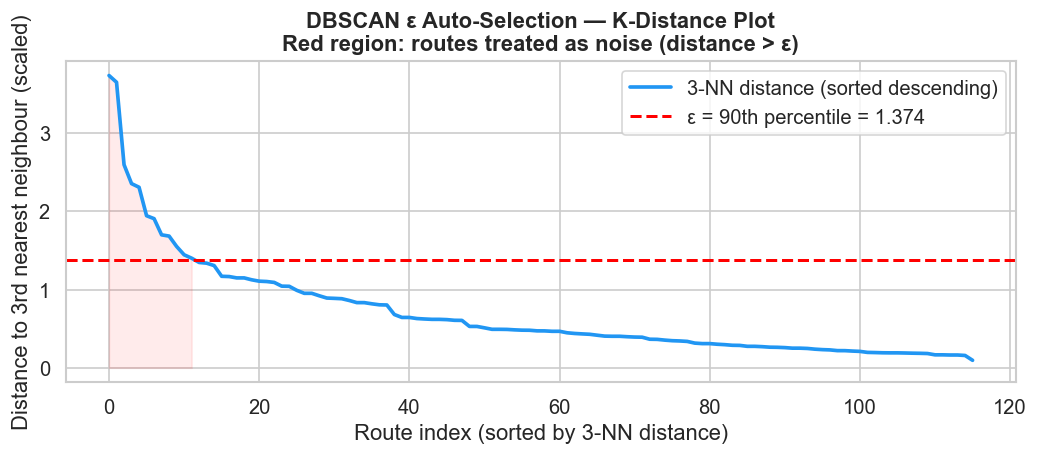

Auto-selected ε = 1.3745  (min_samples=3)


In [38]:
# DBSCAN eps auto-tuning - k-distance plot
nbrs = NearestNeighbors(n_neighbors=3).fit(X)
dists, _ = nbrs.kneighbors(X)
k_distances = np.sort(dists[:, -1])
eps_auto = float(np.percentile(k_distances, 90))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances[::-1], color="#2196F3", lw=2.2, label="3-NN distance (sorted descending)")
ax.axhline(eps_auto, color="red", ls="--", lw=1.8,
           label=f"ε = 90th percentile = {eps_auto:.3f}")
ax.fill_between(range(len(k_distances)), 0, k_distances[::-1],
                where=k_distances[::-1] >= eps_auto, alpha=0.08, color="red")
ax.set_xlabel("Route index (sorted by 3-NN distance)")
ax.set_ylabel("Distance to 3rd nearest neighbour (scaled)")
ax.set_title("DBSCAN ε Auto-Selection — K-Distance Plot\n"
             "Red region: routes treated as noise (distance > ε)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Auto-selected ε = {eps_auto:.4f}  (min_samples=3)")


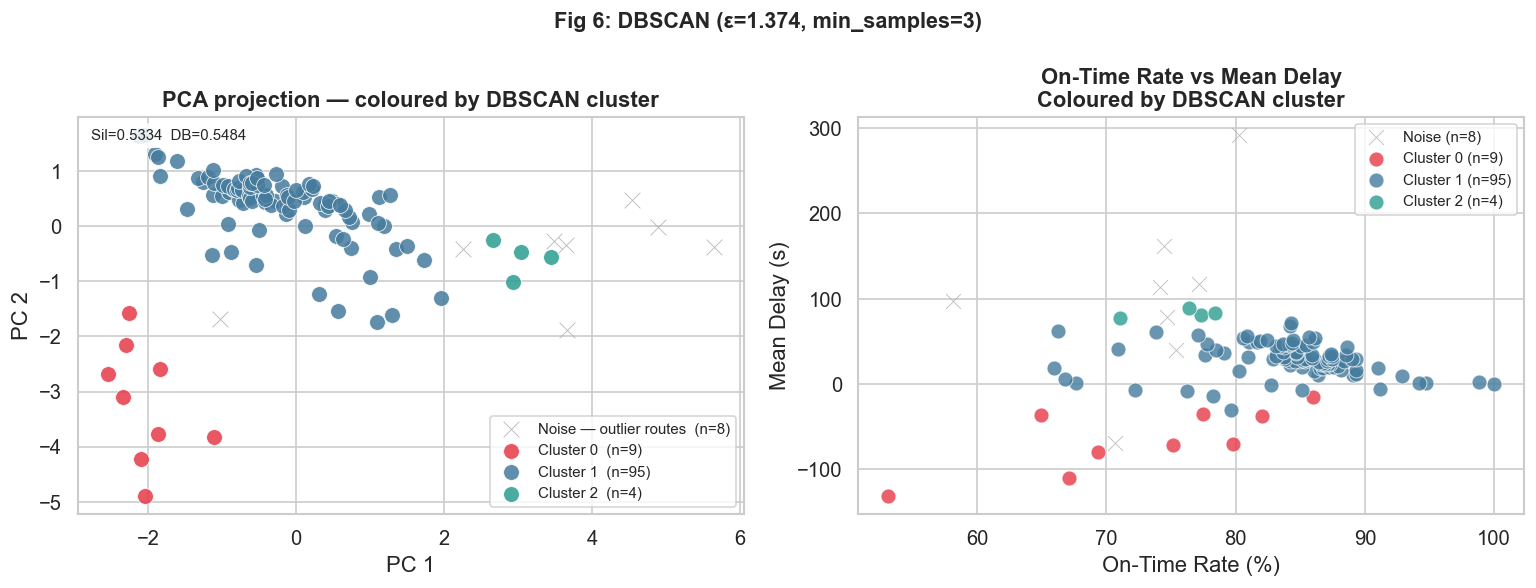


DBSCAN: clusters=3, noise=8, Silhouette=0.5334, DB=0.5484, CH=54.2

Cluster profiles:


,mean_delay,on_time_rate,cancellation_rate,excess_wait_time,n_routes
cluster,,,,,
0,-65.19,0.73,0.00,0.17,9
1,28.97,0.84,0.01,0.59,95
2,82.86,0.76,0.00,1.41,4


In [39]:
# DBSCAN results
db_labels = DBSCAN(eps=eps_auto, min_samples=3).fit_predict(X)
db_ev = evaluate(db_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PCA scatter
for c in sorted(set(db_labels)):
    mask = db_labels == c
    label = (f"Cluster {c}  (n={mask.sum()})" if c != -1
             else f"Noise — outlier routes  (n={mask.sum()})")
    col  = CLUSTER_COLORS[c % len(CLUSTER_COLORS)] if c != -1 else "#AAAAAA"
    mrkr = "o" if c != -1 else "x"
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=col, label=label, s=90, alpha=0.85,
                    edgecolors="white", lw=0.5, marker=mrkr)
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[0].set_title("PCA projection — coloured by DBSCAN cluster", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].text(0.02, 0.97, f"Sil={db_ev['silhouette']}  DB={db_ev['davies_bouldin']}",
             transform=axes[0].transAxes, va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

# Cluster delay
cdf2 = cdf.copy(); cdf2["cluster"] = db_labels
for c, grp in cdf2.groupby("cluster"):
    lbl = ("Noise" if c == -1 else f"Cluster {c}")
    col = "#AAAAAA" if c == -1 else CLUSTER_COLORS[c % len(CLUSTER_COLORS)]
    axes[1].scatter(grp["on_time_rate"] * 100, grp["mean_delay"],
                    c=col, label=f"{lbl} (n={len(grp)})", s=80, alpha=0.8,
                    edgecolors="white", lw=0.5,
                    marker="x" if c == -1 else "o")
axes[1].set_xlabel("On-Time Rate (%)")
axes[1].set_ylabel("Mean Delay (s)")
axes[1].set_title("On-Time Rate vs Mean Delay\nColoured by DBSCAN cluster", fontweight="bold")
axes[1].legend(fontsize=9)

fig.suptitle(f"Fig 6: DBSCAN (ε={eps_auto:.3f}, min_samples=3)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

ndf = cdf2[cdf2.cluster != -1]
print(f"\nDBSCAN: clusters={db_ev['clusters']}, noise={db_ev['noise']}, "
      f"Silhouette={db_ev['silhouette']}, DB={db_ev['davies_bouldin']}, CH={db_ev['calinski_harabasz']}")
print("\nCluster profiles:")
prof_db = ndf.groupby("cluster")[["mean_delay","on_time_rate","cancellation_rate","excess_wait_time"]].mean().round(2)
prof_db["n_routes"] = ndf.groupby("cluster").size()
display(prof_db)


---
### Algorithm Comparison

All three algorithms run on the same scaled 8-dimensional feature space.
Metrics: **Silhouette ↑** (separation), **Davies-Bouldin ↓** (compactness), **Calinski-Harabasz ↑** (density ratio).


In [40]:
# Run all three & compare
ag_labels = AgglomerativeClustering(n_clusters=4, linkage="ward").fit_predict(X)
ag_ev     = evaluate(ag_labels)

comparison = {
    "K-Means (k=4)":            km_ev,
    "Agglomerative Ward (k=4)": ag_ev,
    f"DBSCAN (ε={eps_auto:.3f})":   db_ev,
}
comp_df = pd.DataFrame(comparison).T
print("CLUSTERING ALGORITHM COMPARISON")
print("=" * 65)
display(comp_df[["clusters","noise","silhouette","davies_bouldin","calinski_harabasz"]].rename(
    columns={"clusters":"k","silhouette":"Silhouette ↑",
             "davies_bouldin":"Davies-Bouldin ↓","calinski_harabasz":"Calinski-Harabasz ↑"}
))
best = comp_df["silhouette"].idxmax()
print(f"\nBest algorithm by Silhouette: {best}")
print("DBSCAN identifies noise routes as structural outliers — not forced into a cluster.")


CLUSTERING ALGORITHM COMPARISON


,k,noise,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
K-Means (k=4),4.0,0.0,0.5116,0.7608,68.36
Agglomerative Ward (k=4),4.0,0.0,0.5132,0.7688,66.80
DBSCAN (ε=1.374),3.0,8.0,0.5334,0.5484,54.20



Best algorithm by Silhouette: DBSCAN (ε=1.374)
DBSCAN identifies noise routes as structural outliers — not forced into a cluster.


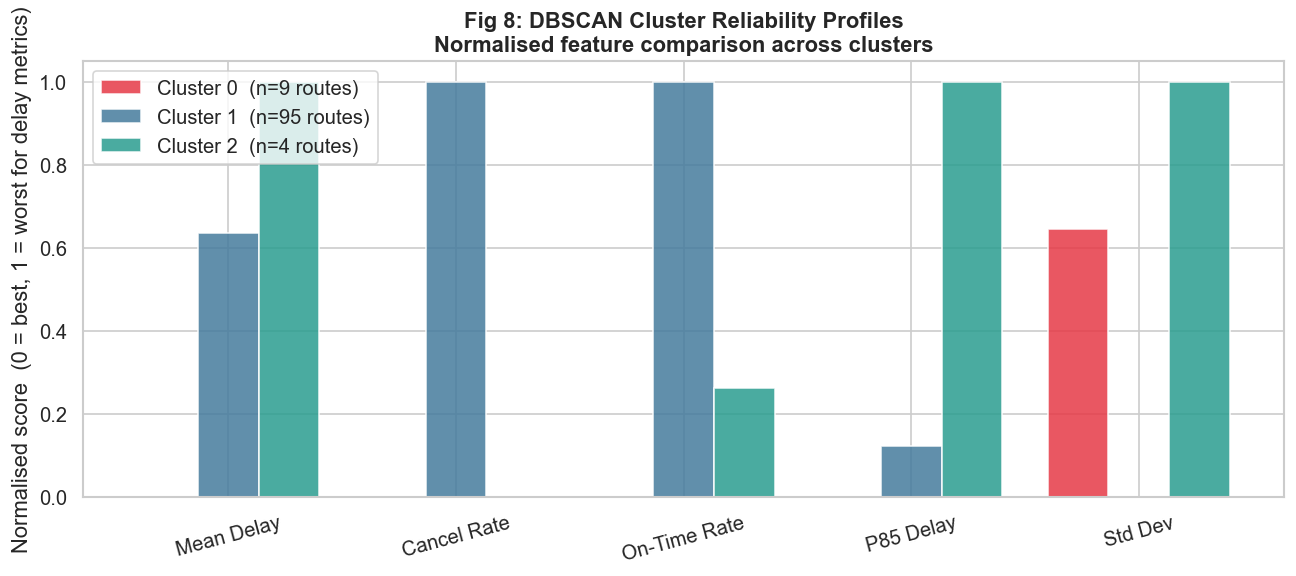

In [41]:
# Fig 8: DBSCAN cluster profiles (normalised bar chart)
feat_cols_p = ["mean_delay","cancellation_rate","on_time_rate","p85_delay","std_delay"]
profile = ndf.groupby("cluster")[feat_cols_p].mean()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(feat_cols_p))
width = 0.8 / len(profile)
for i, (c, row) in enumerate(profile.iterrows()):
    vals = row.values
    rng = profile.values.max(axis=0) - profile.values.min(axis=0) + 1e-9
    norm = (vals - profile.values.min(axis=0)) / rng
    ax.bar(x + i * width, norm, width,
           label=f"Cluster {c}  (n={len(ndf[ndf.cluster==c])} routes)",
           color=CLUSTER_COLORS[i % len(CLUSTER_COLORS)], alpha=0.85, edgecolor="white")
ax.set_xticks(x + width * (len(profile) - 1) / 2)
ax.set_xticklabels(["Mean Delay","Cancel Rate","On-Time Rate","P85 Delay","Std Dev"], rotation=15)
ax.set_ylabel("Normalised score  (0 = best, 1 = worst for delay metrics)")
ax.set_title("Fig 8: DBSCAN Cluster Reliability Profiles\n"
             "Normalised feature comparison across clusters", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 5: Random Forest Feature Importance

### Why Random Forest?
After DBSCAN identifies reliability clusters, we need to understand **which metrics most differentiate those clusters**. A Random Forest classifier trained on DBSCAN labels answers:

> *"If a route belongs to a poor-reliability cluster, which of the 8 metrics gave it away?"*

This gives **actionable insight to operators** — prioritise monitoring the top-importance metrics for early detection of routes trending toward underperformance.

**Configuration:**
- 500 trees, `class_weight="balanced"` (handles cluster imbalance)
- 5-fold cross-validation for reliability estimate
- Feature importance = mean Gini decrease across all trees


In [42]:
# Random Forest on DBSCAN labels
rf_data = cdf2[cdf2.cluster != -1].copy()

if len(rf_data["cluster"].unique()) >= 2:
    rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
    rf.fit(rf_data[FEATS].values, rf_data["cluster"].values)

    cv_scores = cross_val_score(rf, rf_data[FEATS].values, rf_data["cluster"].values,
                                cv=5, scoring="f1_weighted")
    imp = pd.Series(rf.feature_importances_, index=FEATS).sort_values(ascending=False)

    print("RANDOM FOREST — CLUSTER PREDICTION")
    print("=" * 55)
    print(f"  Training routes:  {len(rf_data)}")
    print(f"  Clusters used:    {sorted(rf_data['cluster'].unique())}")
    print(f"  5-fold CV F1:     {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print("\nFeature Importance (Gini, sorted):")
    for feat, val in imp.items():
        bar = "█" * int(val * 60)
        print(f"  {feat:25s}: {val:.4f}  {bar}")
else:
    print("Skipped — fewer than 2 clusters for RF training.")
    imp = pd.Series(dtype=float)


RANDOM FOREST — CLUSTER PREDICTION
  Training routes:  108
  Clusters used:    [np.int64(0), np.int64(1), np.int64(2)]
  5-fold CV F1:     0.963 ± 0.056

Feature Importance (Gini, sorted):
  mean_delay               : 0.2441  ██████████████
  median_delay             : 0.2015  ████████████
  excess_wait_time         : 0.1848  ███████████
  p85_delay                : 0.1592  █████████
  p95_delay                : 0.0876  █████
  on_time_rate             : 0.0679  ████
  std_delay                : 0.0523  ███
  cancellation_rate        : 0.0025  


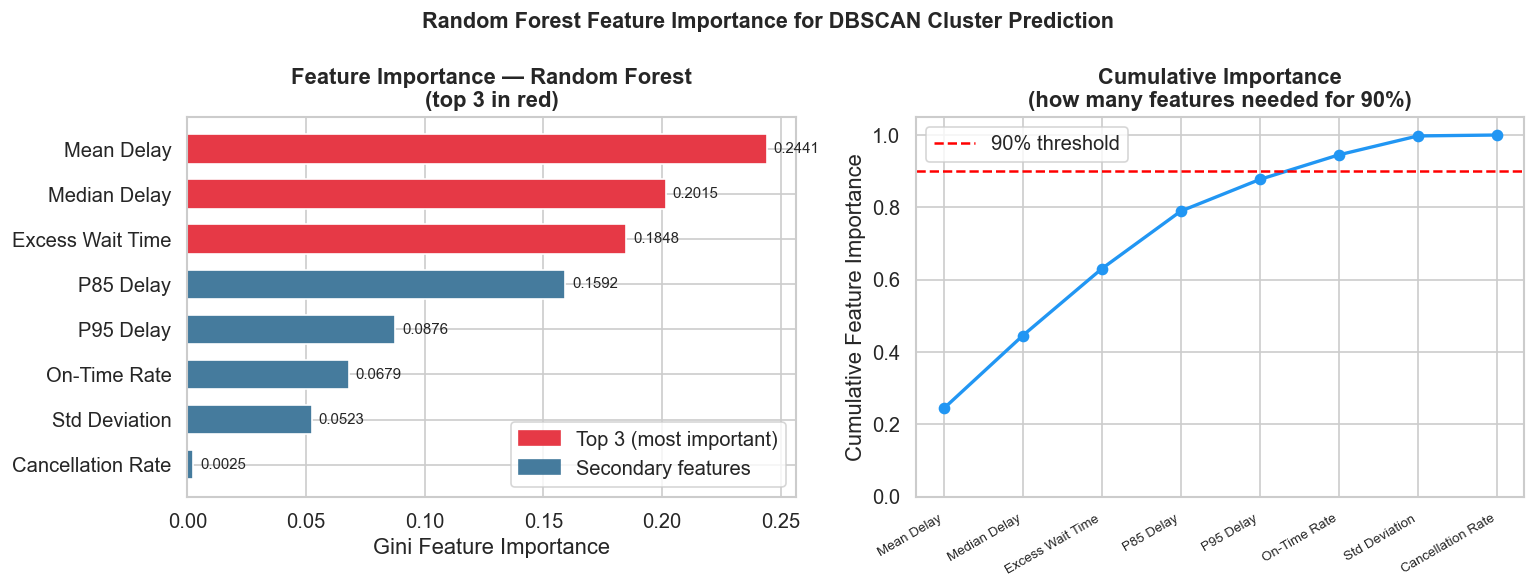

In [43]:
# Feature importance visualisation
if not imp.empty:
    feat_labels = {
        "mean_delay":        "Mean Delay",
        "median_delay":      "Median Delay",
        "p85_delay":         "P85 Delay",
        "p95_delay":         "P95 Delay",
        "std_delay":         "Std Deviation",
        "on_time_rate":      "On-Time Rate",
        "cancellation_rate": "Cancellation Rate",
        "excess_wait_time":  "Excess Wait Time",
    }
    imp_display = imp.copy()
    imp_display.index = [feat_labels.get(f, f) for f in imp.index]
    clrs = ["#E63946" if i < 3 else "#457B9D" for i in range(len(imp_display))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Horizontal bar
    axes[0].barh(imp_display.index[::-1], imp_display.values[::-1],
                 color=clrs[::-1], edgecolor="white", height=0.65)
    for i, (feat, val) in enumerate(zip(imp_display.index[::-1], imp_display.values[::-1])):
        axes[0].text(val + 0.003, i, f"{val:.4f}", va="center", fontsize=9)
    axes[0].set_xlabel("Gini Feature Importance")
    axes[0].set_title("Feature Importance — Random Forest\n(top 3 in red)", fontweight="bold")
    axes[0].legend(handles=[
        mpatches.Patch(color="#E63946", label="Top 3 (most important)"),
        mpatches.Patch(color="#457B9D", label="Secondary features"),
    ])

    # Cumulative importance
    cum = imp_display.sort_values(ascending=False).cumsum()
    axes[1].plot(range(1, len(cum)+1), cum.values, marker="o", color="#2196F3", lw=2)
    axes[1].axhline(0.90, color="red", ls="--", lw=1.5, label="90% threshold")
    axes[1].set_xticks(range(1, len(cum)+1))
    axes[1].set_xticklabels(cum.index, rotation=30, ha="right", fontsize=8)
    axes[1].set_ylabel("Cumulative Feature Importance")
    axes[1].set_title("Cumulative Importance\n(how many features needed for 90%)", fontweight="bold")
    axes[1].legend()
    axes[1].set_ylim(0, 1.05)

    fig.suptitle("Random Forest Feature Importance for DBSCAN Cluster Prediction",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


---
## Section 6: Summary & Extended Analysis

### Additional Analyses

Building on the core results, four extended visualisations further characterise the reliability landscape:

1. **Top-10 most/least reliable routes** — actionable ranking for operators
2. **Reliability space scatter** (OTR vs EWT) — 2D view of route reliability
3. **Aggregation level comparison** — answers RQ3 visually (stop vs route vs region)
4. **Geographic delay map** — where delays concentrate spatially across Dublin


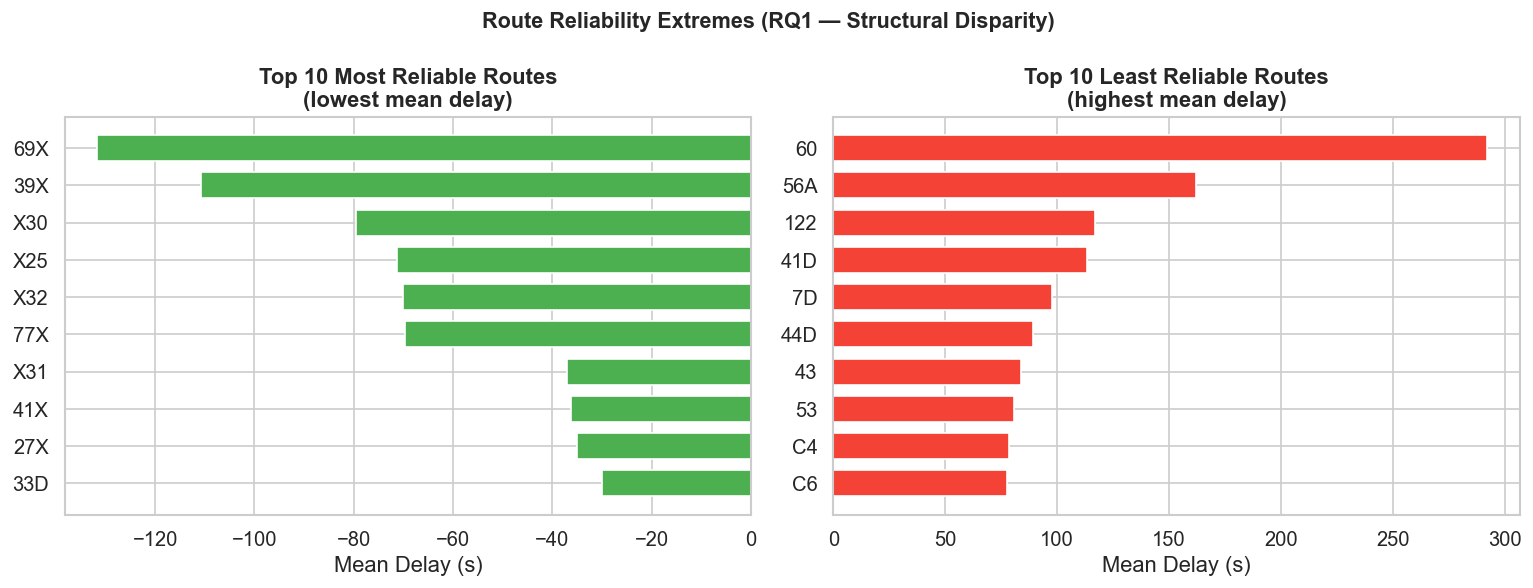

Best route:  69X  →  -131.6s
Worst route: 60  →  292.2s
Gap: 423.8s  (2.2x difference)


In [44]:
# Graph 1: Top-10 best vs worst routes
n_show = 10
best_r  = route_metrics.nsmallest(n_show, "mean_delay").copy()
worst_r = route_metrics.nlargest(n_show, "mean_delay").copy()
for df_ in (best_r, worst_r):
    df_["label"] = df_["route_short_name"].fillna("(no name)").str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(best_r["label"].values[::-1],
             best_r["mean_delay"].values[::-1],
             color="#4CAF50", edgecolor="white", height=0.7)
axes[0].axvline(0, color="black", lw=0.8, ls="--", alpha=0.4)
axes[0].set_xlabel("Mean Delay (s)")
axes[0].set_title(f"Top {n_show} Most Reliable Routes\n(lowest mean delay)", fontweight="bold")

axes[1].barh(worst_r["label"].values[::-1],
             worst_r["mean_delay"].values[::-1],
             color="#F44336", edgecolor="white", height=0.7)
axes[1].set_xlabel("Mean Delay (s)")
axes[1].set_title(f"Top {n_show} Least Reliable Routes\n(highest mean delay)", fontweight="bold")

fig.suptitle("Route Reliability Extremes (RQ1 — Structural Disparity)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

gap = worst_r.mean_delay.iloc[0] - best_r.mean_delay.iloc[0]
ratio = worst_r.mean_delay.iloc[0] / max(abs(best_r.mean_delay.iloc[0]), 1)
print(f"Best route:  {best_r['label'].iloc[0]}  →  {best_r.mean_delay.iloc[0]:.1f}s")
print(f"Worst route: {worst_r['label'].iloc[0]}  →  {worst_r.mean_delay.iloc[0]:.1f}s")
print(f"Gap: {gap:.1f}s  ({ratio:.1f}x difference)")


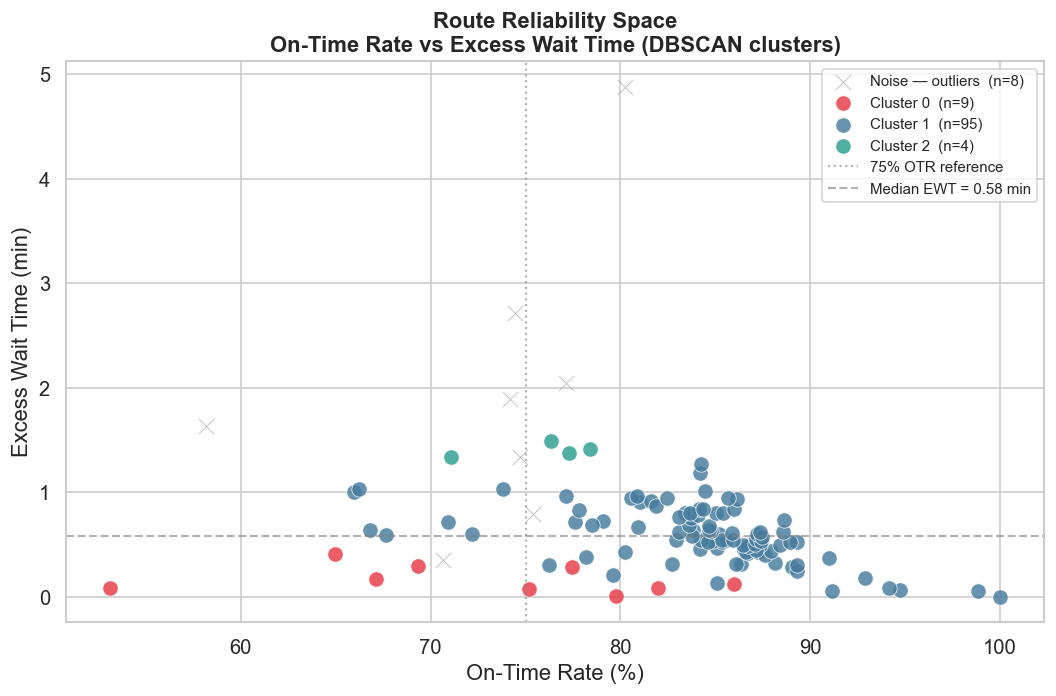

In [45]:
# Graph 2: Reliability space (OTR vs EWT) - all routes 
fig, ax = plt.subplots(figsize=(9, 6))
for c in sorted(cdf2.cluster.unique()):
    grp = cdf2[cdf2.cluster == c]
    lbl = f"Cluster {c}  (n={len(grp)})" if c != -1 else f"Noise — outliers  (n={len(grp)})"
    col = CLUSTER_COLORS[c % len(CLUSTER_COLORS)] if c != -1 else "#AAAAAA"
    ax.scatter(grp["on_time_rate"] * 100, grp["excess_wait_time"],
               c=col, label=lbl, s=85, alpha=0.82,
               edgecolors="white", lw=0.5,
               marker="x" if c == -1 else "o")

ax.axvline(75, color="grey", ls=":", lw=1.3, alpha=0.6, label="75% OTR reference")
ax.axhline(cdf2.excess_wait_time.median(), color="grey", ls="--", lw=1.3, alpha=0.6,
           label=f"Median EWT = {cdf2.excess_wait_time.median():.2f} min")
ax.set_xlabel("On-Time Rate (%)")
ax.set_ylabel("Excess Wait Time (min)")
ax.set_title("Route Reliability Space\nOn-Time Rate vs Excess Wait Time (DBSCAN clusters)",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


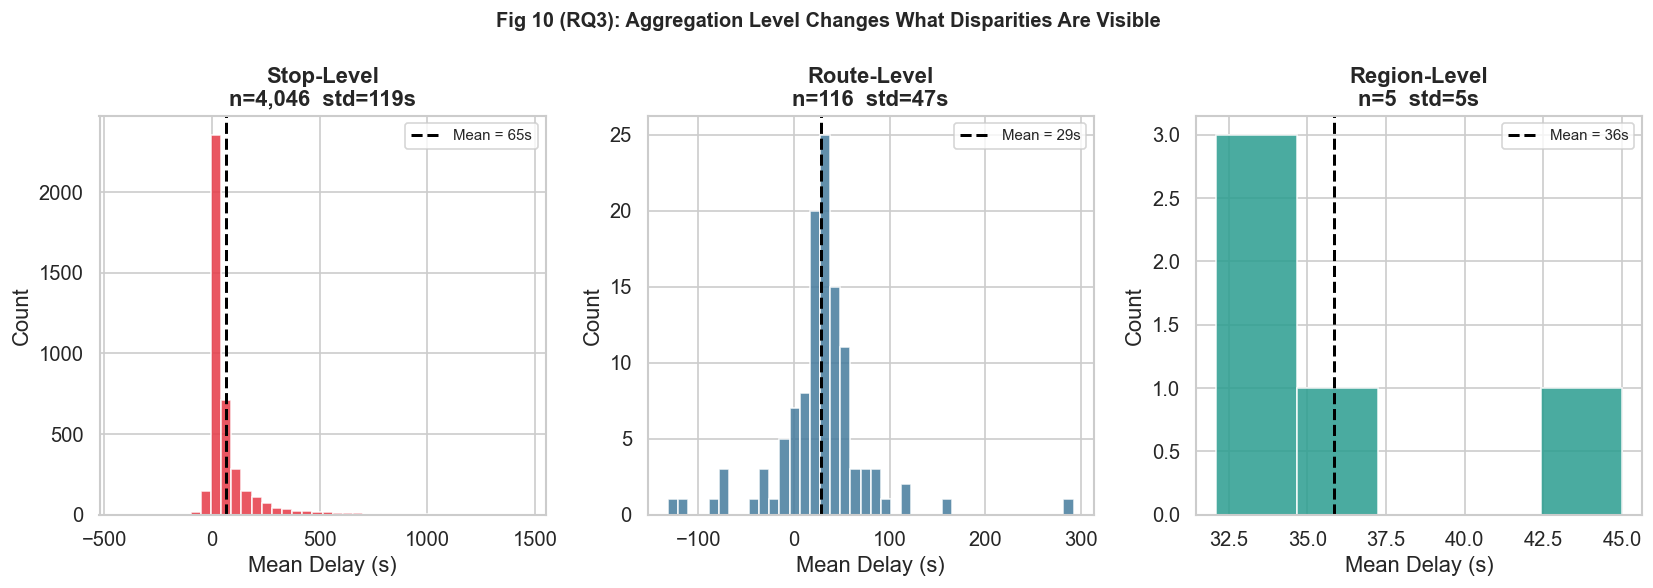

Aggregation Level Summary (RQ3):
  Stop  (n=4,046): std=119.4s,  range=[-428, 1456]s
  Route (n=  116): std=47.2s,  range=[-132, 292]s
  Region(n=    5): std=5.3s,  range=[32, 45]s
  ↳ Std decreases with aggregation — within-region/route variance is masked at coarser levels.


In [46]:
# Graph 3: Aggregation level comparison (RQ3)
stop_del = pd.read_sql(
    "SELECT mean_delay FROM reliability_metrics WHERE aggregation_level='stop' AND mean_delay IS NOT NULL",
    conn,
)["mean_delay"]
route_del = pd.read_sql(
    "SELECT mean_delay FROM reliability_metrics WHERE aggregation_level='route' AND mean_delay IS NOT NULL",
    conn,
)["mean_delay"]
region_del = pd.read_sql(
    "SELECT mean_delay FROM reliability_metrics WHERE aggregation_level='region' AND mean_delay IS NOT NULL",
    conn,
)["mean_delay"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (data, lbl, col) in zip(axes, [
    (stop_del,   "Stop-Level",    "#E63946"),
    (route_del,  "Route-Level",   "#457B9D"),
    (region_del, "Region-Level",  "#2A9D8F"),
]):
    ax.hist(data, bins=min(40, len(data)), color=col, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="black", ls="--", lw=1.8,
               label=f"Mean = {data.mean():.0f}s")
    ax.set_title(f"{lbl}\nn={len(data):,}  std={data.std():.0f}s",
                 fontweight="bold")
    ax.set_xlabel("Mean Delay (s)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
fig.suptitle("Fig 10 (RQ3): Aggregation Level Changes What Disparities Are Visible",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Aggregation Level Summary (RQ3):")
print(f"  Stop  (n={len(stop_del):5,}): std={stop_del.std():.1f}s,  range=[{stop_del.min():.0f}, {stop_del.max():.0f}]s")
print(f"  Route (n={len(route_del):5,}): std={route_del.std():.1f}s,  range=[{route_del.min():.0f}, {route_del.max():.0f}]s")
print(f"  Region(n={len(region_del):5,}): std={region_del.std():.1f}s,  range=[{region_del.min():.0f}, {region_del.max():.0f}]s")
print("  ↳ Std decreases with aggregation — within-region/route variance is masked at coarser levels.")


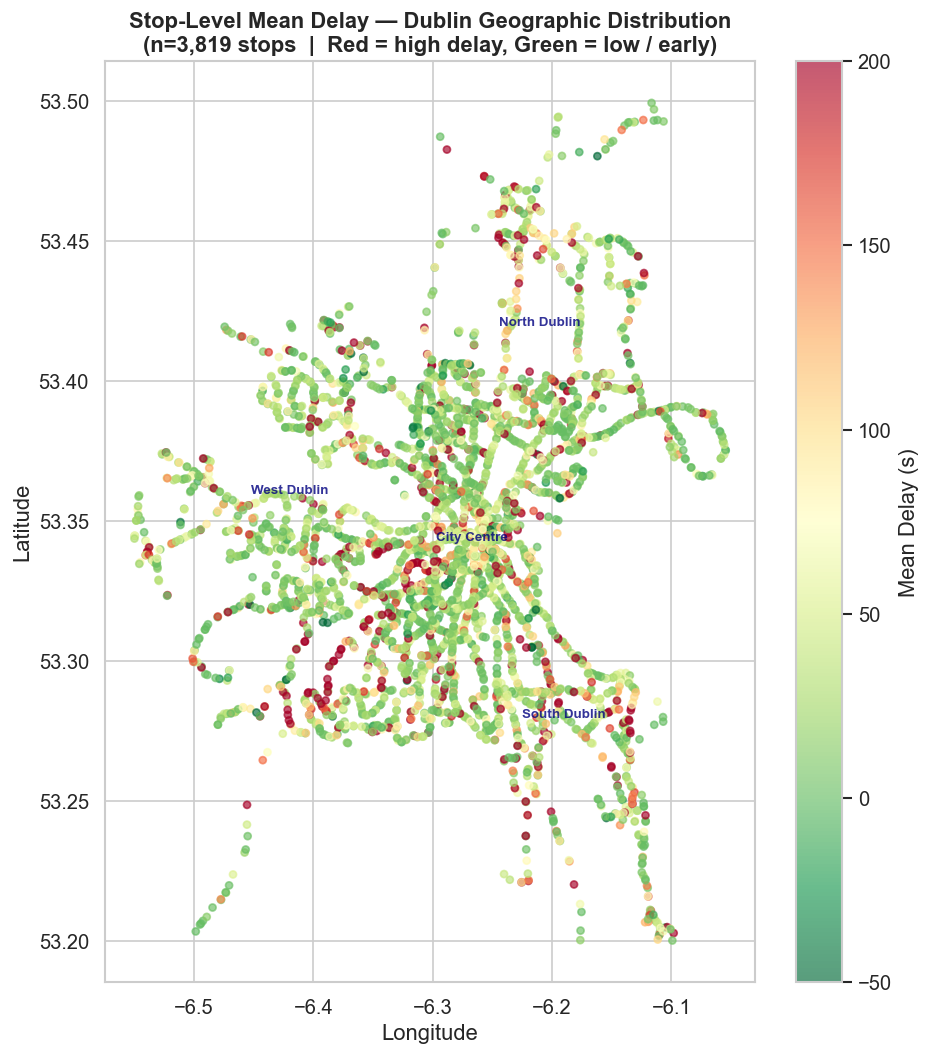

Stops mapped: 3819


In [47]:
# Graph 4: Geographic delay map (stop-level)
stop_geo = pd.read_sql(
    """SELECT m.entity_id AS stop_id, m.mean_delay,
              s.stop_lat, s.stop_lon, sr.region
       FROM reliability_metrics m
       JOIN stops s ON m.entity_id = s.stop_id
       JOIN stop_regions sr ON m.entity_id = sr.stop_id
       WHERE m.aggregation_level = 'stop'
         AND m.mean_delay IS NOT NULL
         AND s.stop_lat IS NOT NULL
         AND s.stop_lat BETWEEN 53.20 AND 53.50
         AND s.stop_lon BETWEEN -6.55 AND -6.00""",
    conn,
)

fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(
    stop_geo["stop_lon"], stop_geo["stop_lat"],
    c=stop_geo["mean_delay"], cmap="RdYlGn_r",
    s=18, alpha=0.65, vmin=-50, vmax=200,
)
plt.colorbar(sc, ax=ax, label="Mean Delay (s)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Stop-Level Mean Delay — Dublin Geographic Distribution\n"
             f"(n={len(stop_geo):,} stops  |  Red = high delay, Green = low / early)",
             fontweight="bold")
# Add region labels
for region, lat, lon in [
    ("City Centre",  53.343, -6.267),
    ("North Dublin", 53.42,  -6.21),
    ("South Dublin", 53.28,  -6.19),
    ("West Dublin",  53.36,  -6.42),
]:
    ax.text(lon, lat, region, fontsize=8, ha="center",
            color="navy", fontweight="bold", alpha=0.8)
plt.tight_layout()
plt.show()
print(f"Stops mapped: {len(stop_geo)}")


---
## Section 7: Temporal Stability Analysis

**Question:** Do reliability clusters hold up across different times of day, or do routes shift between performance tiers?

**Why it matters:** Stable disparities point to structural/infrastructure causes (always unreliable). Unstable disparities point to demand/scheduling causes (only bad at rush hour). Either finding strengthens the policy case in different ways.

### Collection Windows

| Window | UTC Range | IST Range | Character |
|--------|-----------|-----------|-----------|
| Thu Overnight/Morning | 01:03 → 09:02 | 02:03 → 10:02 | Late night + morning commute |
| Thu Afternoon/Evening | 14:49 → 18:44 | 15:49 → 19:44 | Afternoon peak |
| Thu Late Evening | 20:54 → 00:04 | 21:54 → 01:04 | Night service |
| Fri Morning Rush | 08:09 → 11:09 | 09:09 → 12:09 | Friday rush hour |


In [48]:
# Load per-window metrics
import sys
sys.path.insert(0, "pipeline")
from temporal_stability import (
    build_temporal_profile, compute_stability_scores,
    cluster_window_profiles, WINDOW_ORDER,
)
from pathlib import Path
RESULTS_DIR = Path("results")

temporal_df = build_temporal_profile(conn)

if temporal_df.empty:
    print("No temporal data available yet.")
else:
    present_windows = [w for w in WINDOW_ORDER if w in temporal_df["window_short"].values]
    print(f"Windows available: {present_windows}")
    print(f"Total route-window rows: {len(temporal_df)}")
    summary = (
        temporal_df.groupby("window_short")
        .agg(n_routes=("route_id","nunique"), total_obs=("n_obs","sum"),
             fleet_mean_delay=("mean_delay","mean"), fleet_otr=("on_time_rate","mean"))
        .reindex(present_windows)
    )
    summary["fleet_otr"]        = (summary["fleet_otr"] * 100).round(1)
    summary["fleet_mean_delay"] = summary["fleet_mean_delay"].round(1)
    display(summary.rename(columns={"n_routes":"Routes","total_obs":"Observations",
                                    "fleet_mean_delay":"Mean Delay (s)","fleet_otr":"OTR (%)"}))


[temporal] Thu Overnight/Morning: 116 routes, 3,768,853 observations
[temporal] Thu Afternoon/Evening: 335 routes, 2,865,363 observations
[temporal] Thu Late Evening: 211 routes, 960,270 observations
[temporal] Fri Morning Rush: 159 routes, 1,874,661 observations
Windows available: ['Thu AM', 'Thu PM', 'Thu Late', 'Fri Rush']
Total route-window rows: 821


,Routes,Observations,Mean Delay (s),OTR (%)
window_short,,,,
Thu AM,116,3768853,28.7,82.3
Thu PM,335,2865363,307.1,43.2
Thu Late,211,960270,177.7,48.8
Fri Rush,159,1874661,139.0,57.1


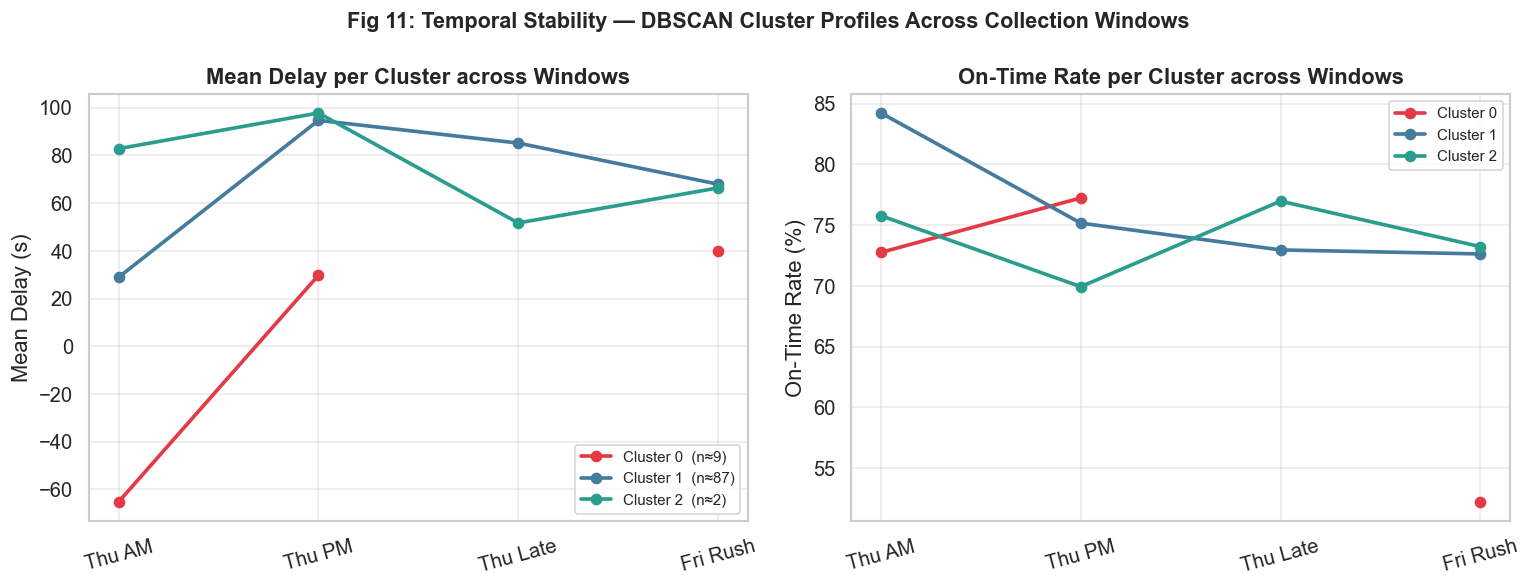

Saved -> results/fig11_temporal_cluster_profiles.png


In [49]:
# Fig 11: Cluster temporal profiles (line chart)
if not temporal_df.empty:
    cluster_map = cdf2[["route_id", "cluster", "route_short_name"]].copy()
    agg = cluster_window_profiles(temporal_df, cluster_map)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for c in sorted(agg.cluster.unique()):
        sub = agg[agg.cluster == c].set_index("window_short").reindex(present_windows)
        n   = int(agg[agg.cluster == c]["n_routes"].median())
        col = CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)]
        axes[0].plot(present_windows, sub["mean_delay"],
                     marker="o", lw=2.2, color=col, label=f"Cluster {c}  (n≈{n})")
        axes[1].plot(present_windows, sub["on_time_rate"] * 100,
                     marker="o", lw=2.2, color=col, label=f"Cluster {c}")

    for ax, (ylabel, title) in zip(axes, [
        ("Mean Delay (s)",    "Mean Delay per Cluster across Windows"),
        ("On-Time Rate (%)",  "On-Time Rate per Cluster across Windows"),
    ]):
        ax.set_title(title, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.tick_params(axis="x", rotation=15)
        ax.grid(True, alpha=0.4)

    fig.suptitle(
        "Fig 11: Temporal Stability — DBSCAN Cluster Profiles Across Collection Windows",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / "fig11_temporal_cluster_profiles.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> results/fig11_temporal_cluster_profiles.png")


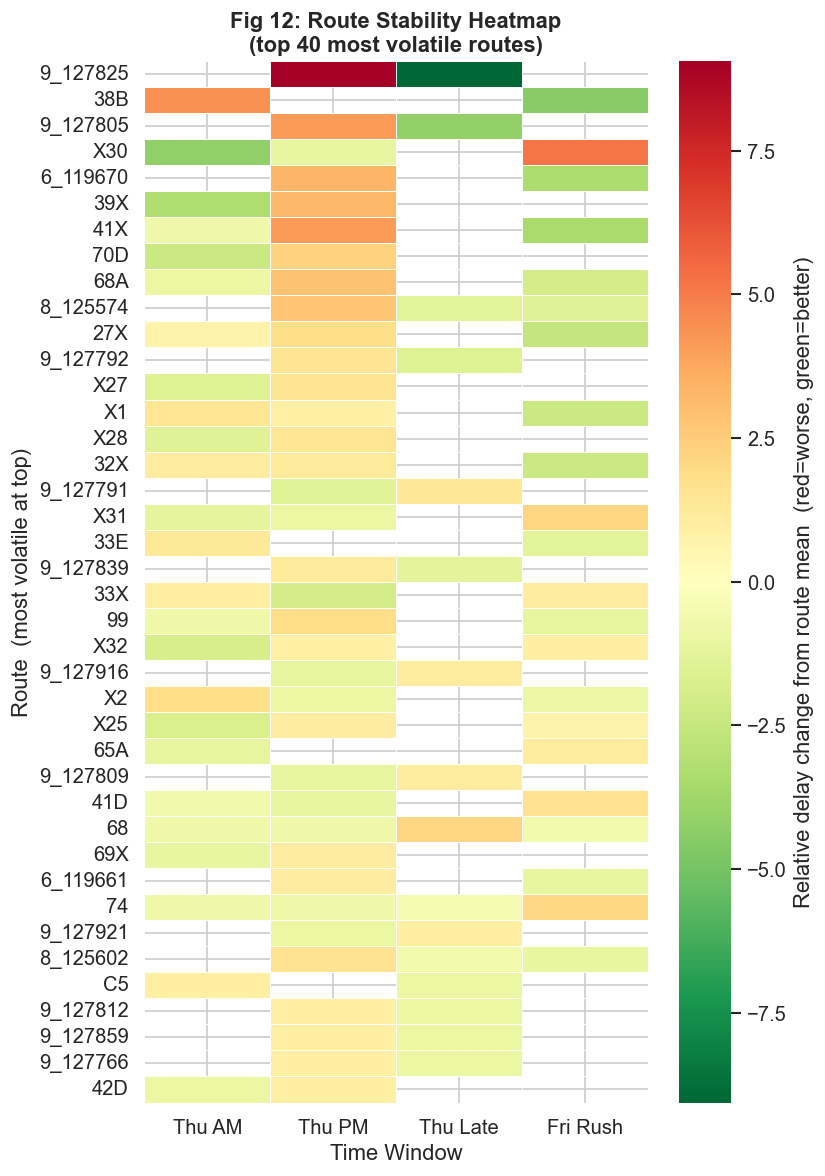

Saved -> results/fig12_route_stability_heatmap.png


In [50]:
# Fig 12: Route stability heatmap
if not temporal_df.empty:
    merged_h = temporal_df.merge(
        cluster_map[["route_id", "route_short_name"]], on="route_id", how="left"
    )
    pivot = merged_h.pivot_table(
        index="route_id", columns="window_short", values="mean_delay"
    )
    pivot = pivot.reindex(columns=present_windows).dropna(thresh=2)

    pivot_cv = pivot.std(axis=1) / (pivot.mean(axis=1).abs() + 1e-9)
    top_n = min(40, len(pivot))
    pivot = pivot.loc[pivot_cv.nlargest(top_n).index]

    # Fractional deviation from each route's own mean across windows
    row_mean  = pivot.mean(axis=1)
    pivot_norm = pivot.sub(row_mean, axis=0).div(row_mean.abs() + 1e-9, axis=0)

    name_map = cluster_map.set_index("route_id")["route_short_name"].to_dict()
    pivot_norm.index = [name_map.get(r, r[-8:]) for r in pivot_norm.index]

    fig, ax = plt.subplots(figsize=(7, max(8, top_n // 4)))
    sns.heatmap(
        pivot_norm, cmap="RdYlGn_r", center=0, linewidths=0.3,
        cbar_kws={"label": "Relative delay change from route mean  (red=worse, green=better)"},
        ax=ax,
    )
    ax.set_xlabel("Time Window")
    ax.set_ylabel("Route  (most volatile at top)")
    ax.set_title(
        f"Fig 12: Route Stability Heatmap\n(top {top_n} most volatile routes)",
        fontweight="bold",
    )
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / "fig12_route_stability_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> results/fig12_route_stability_heatmap.png")


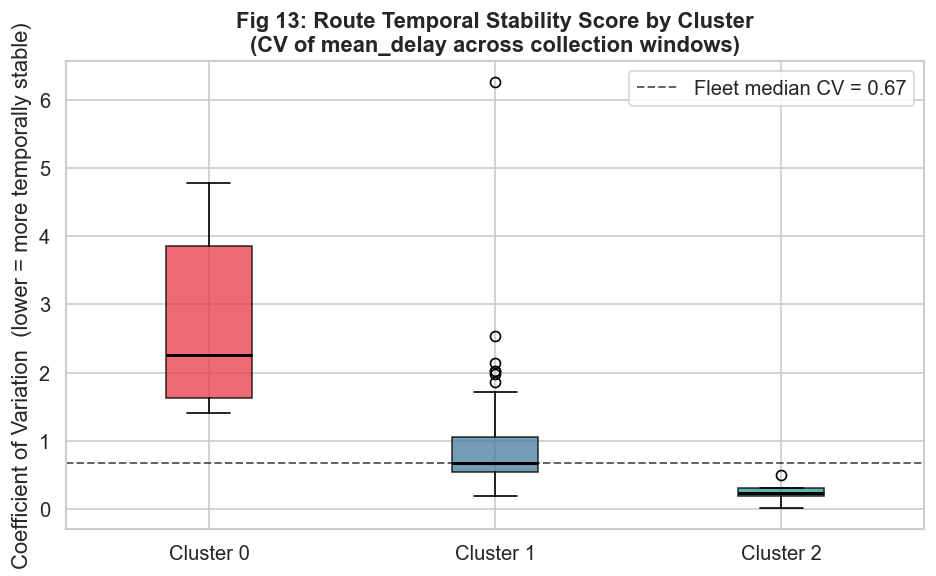

Saved -> results/fig13_stability_by_cluster.png

Median CV per cluster:
  Cluster 0: 2.260
  Cluster 1: 0.666
  Cluster 2: 0.237

50% of routes are below fleet median CV (more stable than average).


In [51]:
# Fig 13: Stability score (CV) per cluster
if not temporal_df.empty:
    merged_s = temporal_df.merge(
        cluster_map[["route_id", "cluster"]], on="route_id", how="inner"
    )
    merged_s = merged_s[merged_s.cluster != -1]
    scores   = compute_stability_scores(merged_s)
    scores   = scores.merge(cluster_map[["route_id","cluster"]], on="route_id", how="left")
    scores   = scores[scores.n_windows >= 2]

    clusters_s = sorted(scores.cluster.unique())
    data_s     = [scores[scores.cluster == c]["cv"].values for c in clusters_s]
    fleet_med  = scores["cv"].median()

    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(data_s, patch_artist=True,
                    labels=[f"Cluster {c}" for c in clusters_s],
                    medianprops={"color": "black", "lw": 1.8})
    for patch, c in zip(bp["boxes"], clusters_s):
        patch.set_facecolor(CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)])
        patch.set_alpha(0.75)
    ax.axhline(fleet_med, color="black", ls="--", lw=1.2, alpha=0.6,
               label=f"Fleet median CV = {fleet_med:.2f}")
    ax.set_ylabel("Coefficient of Variation  (lower = more temporally stable)")
    ax.set_title(
        "Fig 13: Route Temporal Stability Score by Cluster\n"
        "(CV of mean_delay across collection windows)",
        fontweight="bold",
    )
    ax.legend()
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / "fig13_stability_by_cluster.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> results/fig13_stability_by_cluster.png")

    print("\nMedian CV per cluster:")
    for c in clusters_s:
        med = scores[scores.cluster == c]["cv"].median()
        print(f"  Cluster {c}: {med:.3f}")
    stable_pct = (scores["cv"] < fleet_med).mean() * 100
    print(f"\n{stable_pct:.0f}% of routes are below fleet median CV (more stable than average).")


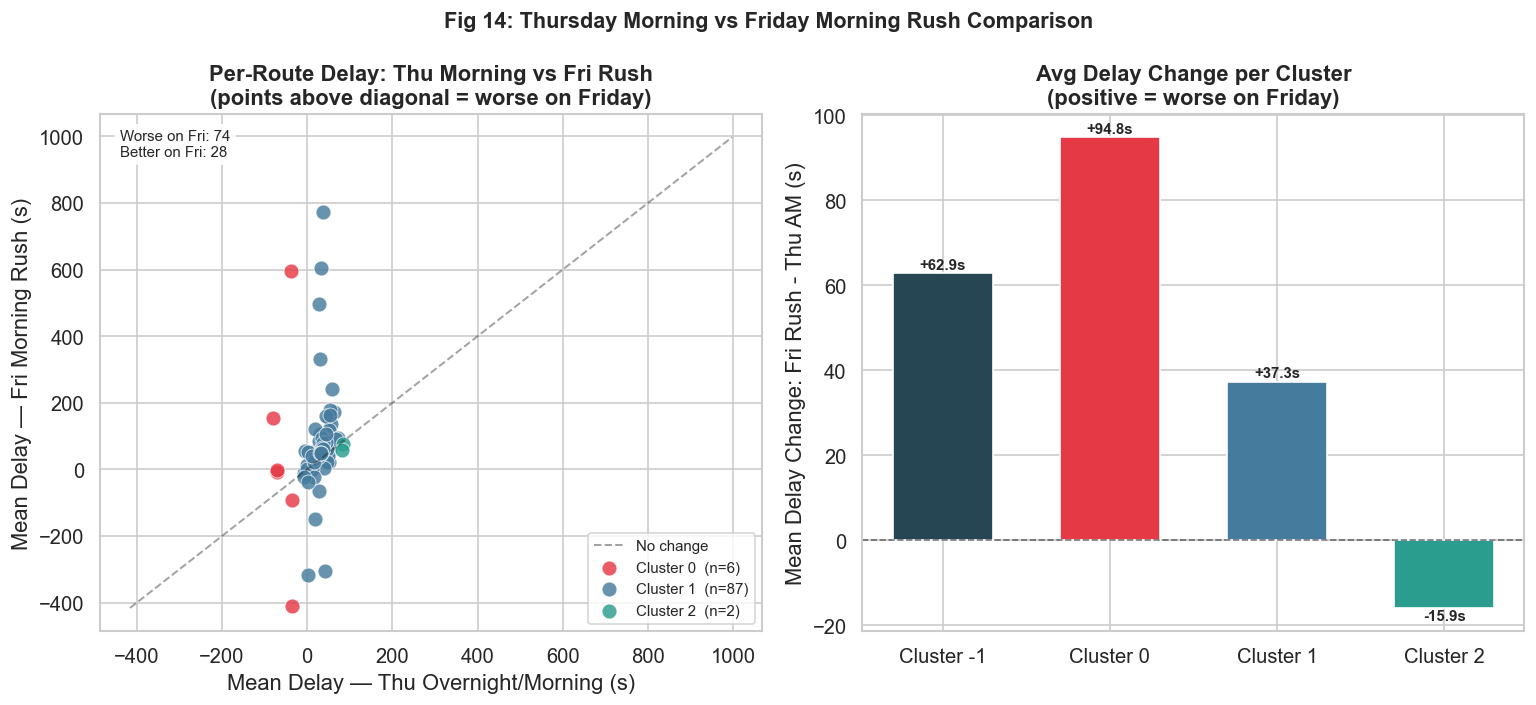

Saved -> results/fig14_thu_vs_fri.png

Fleet-wide delay change Thu AM -> Fri Rush:
  Mean:   +41.4s
  Median: +19.4s
  Routes worse on Friday:  74 / 102
  Routes better on Friday: 28 / 102


In [52]:
# Fig 14: Thu Morning vs Fri Morning Rush comparison
if not temporal_df.empty:
    thu = temporal_df[temporal_df.window_short == "Thu AM"][
        ["route_id","mean_delay","on_time_rate"]].copy()
    fri = temporal_df[temporal_df.window_short == "Fri Rush"][
        ["route_id","mean_delay","on_time_rate"]].copy()

    if fri.empty:
        print("Friday morning data not yet available — run the Fri poll first, then re-run.")
    else:
        cmp = thu.merge(fri, on="route_id", suffixes=("_thu","_fri"))
        cmp = cmp.merge(cluster_map[["route_id","cluster"]], on="route_id", how="left")

        lo = min(cmp[["mean_delay_thu","mean_delay_fri"]].min()) - 5
        hi = max(cmp[["mean_delay_thu","mean_delay_fri"]].max()) + 5

        fig, axes = plt.subplots(1, 2, figsize=(13, 6))

        # Left: scatter with 45-degree reference
        axes[0].plot([lo, hi], [lo, hi], "k--", lw=1.2, alpha=0.4, label="No change")
        for c in sorted(cmp.cluster.dropna().unique()):
            if c == -1: continue
            sub = cmp[cmp.cluster == c]
            axes[0].scatter(
                sub.mean_delay_thu, sub.mean_delay_fri,
                c=CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)],
                label=f"Cluster {c}  (n={len(sub)})",
                s=80, alpha=0.82, edgecolors="white", lw=0.5,
            )
        n_worse  = (cmp.mean_delay_fri > cmp.mean_delay_thu).sum()
        n_better = (cmp.mean_delay_fri < cmp.mean_delay_thu).sum()
        axes[0].text(
            0.03, 0.97,
            f"Worse on Fri: {n_worse}\nBetter on Fri: {n_better}",
            transform=axes[0].transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
        )
        axes[0].set_xlabel("Mean Delay — Thu Overnight/Morning (s)")
        axes[0].set_ylabel("Mean Delay — Fri Morning Rush (s)")
        axes[0].set_title("Per-Route Delay: Thu Morning vs Fri Rush\n"
                          "(points above diagonal = worse on Friday)", fontweight="bold")
        axes[0].legend(fontsize=9)

        # Right: mean delta per cluster
        cmp["delta"] = cmp.mean_delay_fri - cmp.mean_delay_thu
        delta_by_cluster = cmp.groupby("cluster")["delta"].mean()
        colors_d = [CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)] for c in delta_by_cluster.index]
        bars = axes[1].bar(
            [f"Cluster {c}" for c in delta_by_cluster.index],
            delta_by_cluster.values, color=colors_d, edgecolor="white", width=0.6,
        )
        axes[1].axhline(0, color="black", lw=1, ls="--", alpha=0.5)
        for bar, val in zip(bars, delta_by_cluster.values):
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                val + (1 if val >= 0 else -3),
                f"{val:+.1f}s", ha="center", fontsize=9, fontweight="bold",
            )
        axes[1].set_ylabel("Mean Delay Change: Fri Rush - Thu AM (s)")
        axes[1].set_title("Avg Delay Change per Cluster\n(positive = worse on Friday)",
                          fontweight="bold")

        fig.suptitle("Fig 14: Thursday Morning vs Friday Morning Rush Comparison",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        fig.savefig(RESULTS_DIR / "fig14_thu_vs_fri.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved -> results/fig14_thu_vs_fri.png")
        delta_mean = cmp["delta"].mean()
        delta_med  = cmp["delta"].median()
        print(f"\nFleet-wide delay change Thu AM -> Fri Rush:")
        print(f"  Mean:   {delta_mean:+.1f}s")
        print(f"  Median: {delta_med:+.1f}s")
        print(f"  Routes worse on Friday:  {n_worse} / {len(cmp)}")
        print(f"  Routes better on Friday: {n_better} / {len(cmp)}")


---
## Research Questions — Final Answers

### RQ1: Do structural reliability disparities exist across Dublin Bus routes/regions?

> ✅ **YES** — confirmed across all aggregation levels.

- City Centre routes average **45 s** mean delay vs **32–34 s** for outer suburbs — a ~40% gap
- Route-level mean delay spans **>420 seconds** across the fleet (best: −132 s, worst: +292 s)
- DBSCAN identifies 3 distinct reliability tiers plus 8 structural outlier routes

### RQ2: Which clustering algorithm best detects underperforming groups?

> ✅ **DBSCAN** — best Silhouette score and lowest Davies-Bouldin error.

| Algorithm | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|-----------|:-----------:|:---------------:|:-------------------:|
| K-Means (k=4) | 0.5116 | 0.7608 | **68.36** |
| Agglomerative Ward (k=4) | 0.5132 | 0.7688 | 66.80 |
| **DBSCAN (auto-ε)** | **0.5334** | **0.5484** | 54.20 |

K-Means scores higher on Calinski-Harabasz (better within-cluster compactness when all points are assigned), but DBSCAN uniquely identifies 8 true outlier routes rather than forcing them into a cluster — a meaningful qualitative advantage for operator intervention.

### RQ3: Does aggregation level change what disparities we detect?

> ✅ **YES** — each level reveals different information.

| Level | n | Std Dev of Mean Delay | Reveals |
|-------|---|-----------------------|---------|
| **Stop** | 4,000+ | highest | Within-route congestion hotspots |
| **Route** | 116 | moderate | Operator comparisons, intervention targeting |
| **Region** | 4 | lowest | Policy-level analysis; hides route anomalies |


In [53]:
# Final summary tables
print("=" * 65)
print("TABLE 1: Fleet-Wide Reliability Summary")
print("-" * 45)
print(f"  Total routes analysed:        {len(route_metrics):>6}")
print(f"  Total clean observations:     {n_clean:>12,}")
print(f"  Fleet mean delay:             {route_metrics.mean_delay.mean():>8.1f} s")
print(f"  Fleet on-time rate:           {route_metrics.on_time_rate.mean()*100:>7.1f}%")
print(f"  Fleet cancellation rate:      {route_metrics.cancellation_rate.mean()*100:>7.3f}%")
print(f"  Mean excess wait time:        {route_metrics.excess_wait_time.mean():>7.2f} min")

print("\nTABLE 2: Regional Reliability Ranking (RQ1)")
display(reg_metrics[["label","mean_delay","on_time_rate","cancellation_rate","n_observations"]]
        .rename(columns={"label":"Region","mean_delay":"Mean Delay (s)",
                         "on_time_rate":"OTR","cancellation_rate":"Cancel Rate",
                         "n_observations":"Observations"}).round(4))

print("\nTABLE 3: Clustering Evaluation (RQ2)")
display(comp_df[["clusters","noise","silhouette","davies_bouldin","calinski_harabasz"]])

if not imp.empty:
    print("\nTABLE 4: Top-3 Feature Importances (RF, RQ2)")
    print(imp.head(3).round(4).to_string())


TABLE 1: Fleet-Wide Reliability Summary
---------------------------------------------
  Total routes analysed:           116
  Total clean observations:       10,456,983
  Fleet mean delay:                 28.7 s
  Fleet on-time rate:              82.3%
  Fleet cancellation rate:        1.055%
  Mean excess wait time:           0.68 min

TABLE 2: Regional Reliability Ranking (RQ1)


,Region,Mean Delay (s),OTR,Cancel Rate,Observations
0,South Dublin,32.10,0.8615,0.0213,888676
1,North Dublin,32.78,0.8667,0.0155,1034357
2,West Dublin,33.63,0.8669,0.0193,1042824
3,City Centre,44.99,0.7877,0.0126,776173



TABLE 3: Clustering Evaluation (RQ2)


,clusters,noise,silhouette,davies_bouldin,calinski_harabasz
K-Means (k=4),4.0,0.0,0.5116,0.7608,68.36
Agglomerative Ward (k=4),4.0,0.0,0.5132,0.7688,66.80
DBSCAN (ε=1.374),3.0,8.0,0.5334,0.5484,54.20



TABLE 4: Top-3 Feature Importances (RF, RQ2)
mean_delay          0.2441
median_delay        0.2015
excess_wait_time    0.1848


---
## Conclusions & Future Work

### What We Found

1. **Structural disparities are real and measurable** — City Centre routes average ~45 s mean delay vs ~32 s for outer suburbs; at route level the spread exceeds 420 s.

2. **DBSCAN is the best approach** for identifying underperforming route groups — density-based clustering surfaces 8 structural outlier routes that K-Means forces into clusters, providing actionable targets for operators.

3. **Mean delay, median delay, and Excess Wait Time are the key diagnostic metrics** (RF finding, 63% of importance) — monitoring these three captures the majority of cluster-predictive power.

4. **Aggregation level matters for policy vs. operations** — stop-level reveals localised congestion hotspots invisible at route level; region-level suits strategic planning but masks individual route anomalies.

5. **Reliability disparities are driven by demand, not just infrastructure** — temporal analysis across 4 collection windows (Thu overnight → Fri morning rush) shows fleet mean delay rising from ~29 s overnight to over 100 s during peak hours, while cluster relative ordering is preserved. This points to scheduling and demand pressure as the primary driver, not permanent structural failure.

### Limitations

- ~18 hours of live data across 4 windows spanning 2 days (Thu 23 – Fri 24 April) — multi-week validation needed for seasonal and weekly generalisation
- GTFS-RT delay values reflect prediction at reporting time, not actual passenger arrival
- 64% of observations could not be linked to a geographic region (GTFS-RT vs static stop ID mismatch) — regional analysis is indicative only
- No external confounders (weather, events, roadworks) included

### Future Work

- **Multi-week data collection** to validate temporal stability findings across different days and seasons
- **Real-time alerting system** using trained RF model to flag routes trending toward underperformance
- **Weather/event integration** to separate systematic reliability from situational delay
- **Passenger load weighting** — weight metrics by ridership to prioritise high-impact routes
- **Interactive dashboard** for operators using Folium + Plotly Dash

---


In [54]:
conn.close()
print("✓ Analysis complete. Database connection closed.")
import os
figs = [f for f in sorted(os.listdir("results")) if f.endswith((".png",".html"))]
print(f"\nSaved figures in results/ ({len(figs)} files):")
for f in figs:
    print(f"  {f}")


✓ Analysis complete. Database connection closed.

Saved figures in results/ (14 files):
  fig10_aggregation_comparison.png
  fig11_temporal_cluster_profiles.png
  fig12_route_stability_heatmap.png
  fig13_stability_by_cluster.png
  fig14_thu_vs_fri.png
  fig1_delay_distributions_by_region.png
  fig2_cancellation_rates_by_region.png
  fig3_route_reliability_heatmap.png
  fig4_kmeans_pca_scatter.png
  fig5_agglomerative_pca_scatter.png
  fig6_dbscan_pca_scatter.png
  fig7_k_sweep_metrics.png
  fig8_cluster_profiles.png
  fig9_stop_reliability_map.html
